In [1]:
# Cell 1: Import All Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
from datetime import datetime

# ML Libraries
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve
)

# Explainability
try:
    import shap
    print("✅ SHAP already installed")
except ImportError:
    import sys
    !{sys.executable} -m pip install shap -q
    import shap

try:
    import lime
    import lime.lime_text
    print("✅ LIME already installed")
except ImportError:
    import sys
    !{sys.executable} -m pip install lime -q
    import lime
    import lime.lime_text

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print(" " * 20 + "✅ ALL LIBRARIES IMPORTED SUCCESSFULLY!")
print("="*70)
print(f"\nNotebook Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

c:\Users\yagni\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ SHAP already installed
✅ LIME already installed
                    ✅ ALL LIBRARIES IMPORTED SUCCESSFULLY!

Notebook Started: 2026-02-27 13:45:50


In [2]:
# Cell 2: Load All Models and Datasets
print("="*70)
print(" " * 20 + "LOADING MODELS & DATA")
print("="*70)

# ── Kaggle models ──
lr_model       = joblib.load('../models/kaggle_logistic_regression.pkl')
rf_model       = joblib.load('../models/kaggle_random_forest.pkl')
xgb_model      = joblib.load('../models/kaggle_xgboost.pkl')
rf_tuned       = joblib.load('../models/kaggle_random_forest_tuned.pkl')
scaler         = joblib.load('../models/kaggle_scaler.pkl')
label_encoders = joblib.load('../models/label_encoders.pkl')
print("✅ Kaggle models loaded (4)")

# ── TF-IDF models ──
lr_tfidf  = joblib.load('../models/reddit_tfidf_logistic_regression.pkl')
rf_tfidf  = joblib.load('../models/reddit_tfidf_random_forest.pkl')
nb_tfidf  = joblib.load('../models/reddit_tfidf_naive_bayes.pkl')
tfidf_vec = joblib.load('../models/tfidf_vectorizer.pkl')
print("✅ TF-IDF models loaded (3)")

# ── SBERT models ──
svm_linear = joblib.load('../models/sbert_linear_svm.pkl')
svm_rbf    = joblib.load('../models/sbert_rbf_svm.pkl')
svm_tuned  = joblib.load('../models/sbert_svm_tuned.pkl')
print("✅ SBERT models loaded (3)")

# ── Embeddings ──
X_train_sbert = np.load('../models/sbert_train_embeddings.npy')
X_test_sbert  = np.load('../models/sbert_test_embeddings.npy')
print("✅ SBERT embeddings loaded")

# ── Datasets ──
kaggle_path  = '../data/raw/Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset Kaggle.csv'
reddit_path  = '../data/processed/reddit_with_features.csv'
df_kaggle    = pd.read_csv(kaggle_path)
df_reddit    = pd.read_csv(reddit_path)
print("✅ Datasets loaded")

# ── Rebuild Kaggle feature matrix ──
categorical_cols = ['exercise','sugar_intake','smoking','alcohol','married','profession']
df_kp = df_kaggle.copy()
df_kp['risk_binary'] = (df_kp['health_risk'] == 'high').astype(int)
for col in categorical_cols:
    df_kp[f'{col}_encoded'] = label_encoders[col].transform(df_kp[col])
df_kp['age_group']      = pd.cut(df_kp['age'], bins=[0,30,50,100], labels=[0,1,2])
df_kp['sleep_quality']  = ((df_kp['sleep']>=7)&(df_kp['sleep']<=9)).astype(int)
df_kp['substance_use']  = ((df_kp['smoking']=='yes')|(df_kp['alcohol']=='yes')).astype(int)
df_kp['lifestyle_score']= (
    (df_kp['exercise'].isin(['medium','high'])).astype(int) +
    (df_kp['sleep_quality']==1).astype(int) +
    (df_kp['sugar_intake']=='low').astype(int) +
    (df_kp['smoking']=='no').astype(int) +
    (df_kp['alcohol']=='no').astype(int)
)
feature_cols = [
    'age','weight','height','sleep','bmi',
    'exercise_encoded','sugar_intake_encoded',
    'smoking_encoded','alcohol_encoded','married_encoded',
    'age_group','sleep_quality','substance_use','lifestyle_score'
]
from sklearn.model_selection import train_test_split
X_kaggle = df_kp[feature_cols]
y_kaggle = df_kp['risk_binary']
X_train_kg, X_test_kg, y_train_kg, y_test_kg = train_test_split(
    X_kaggle, y_kaggle, test_size=0.2, stratify=y_kaggle, random_state=42)
X_train_kg_scaled = scaler.transform(X_train_kg)
X_test_kg_scaled  = scaler.transform(X_test_kg)

# ── Reddit text split ──
X_reddit_text = df_reddit['cleaned_text'].values
y_reddit      = df_reddit['risk_label'].values
_, X_test_text, _, y_test_text = train_test_split(
    X_reddit_text, y_reddit, test_size=0.2, stratify=y_reddit, random_state=42)
X_test_tfidf = tfidf_vec.transform(X_test_text)

print("\n" + "="*70)
print("✅ ALL MODELS AND DATA LOADED SUCCESSFULLY!")
print(f"   Kaggle test set  : {X_test_kg.shape[0]:,} samples")
print(f"   Reddit test set  : {len(X_test_text):,} samples")
print("="*70)

                    LOADING MODELS & DATA
✅ Kaggle models loaded (4)
✅ TF-IDF models loaded (3)
✅ SBERT models loaded (3)
✅ SBERT embeddings loaded
✅ Datasets loaded

✅ ALL MODELS AND DATA LOADED SUCCESSFULLY!
   Kaggle test set  : 1,000 samples
   Reddit test set  : 3,812 samples


In [3]:
# Cell 3: Master Performance Summary Table (All 10 Models)
print("="*70)
print(" " * 15 + "MASTER PERFORMANCE SUMMARY - ALL MODELS")
print("="*70)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def quick_eval(model, X_test, y_test, name, has_proba=True):
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    auc = None
    if has_proba and hasattr(model, 'predict_proba'):
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    return {'Model': name, 'Accuracy': round(acc,4),
            'Precision': round(p,4), 'Recall': round(r,4),
            'F1-Score': round(f,4), 'ROC-AUC': round(auc,4) if auc else 'N/A'}

results = []
results.append(quick_eval(lr_model,  X_test_kg_scaled,  y_test_kg,   'LR (Kaggle)'))
results.append(quick_eval(rf_model,  X_test_kg_scaled,  y_test_kg,   'RF (Kaggle)'))
results.append(quick_eval(xgb_model, X_test_kg_scaled,  y_test_kg,   'XGBoost (Kaggle)'))
results.append(quick_eval(rf_tuned,  X_test_kg_scaled,  y_test_kg,   'RF Tuned (Kaggle)'))
results.append(quick_eval(lr_tfidf,  X_test_tfidf,      y_test_text, 'LR (TF-IDF)'))
results.append(quick_eval(rf_tfidf,  X_test_tfidf,      y_test_text, 'RF (TF-IDF)'))
results.append(quick_eval(nb_tfidf,  X_test_tfidf,      y_test_text, 'NB (TF-IDF)'))
results.append(quick_eval(svm_rbf,   X_test_sbert,      y_test_text, 'SBERT + RBF SVM'))
results.append(quick_eval(svm_tuned, X_test_sbert,      y_test_text, 'SBERT + SVM Tuned'))

# Linear SVM (no predict_proba)
y_pred_lin = svm_linear.predict(X_test_sbert)
p,r,f,_ = precision_recall_fscore_support(y_test_text, y_pred_lin, average='weighted')
results.append({'Model':'SBERT + Linear SVM',
                'Accuracy':round(accuracy_score(y_test_text,y_pred_lin),4),
                'Precision':round(p,4),'Recall':round(r,4),
                'F1-Score':round(f,4),'ROC-AUC':'N/A'})

master_df = pd.DataFrame(results)
print("\n✅ Complete Model Performance Table:")
print("="*70)
print(master_df.to_string(index=False))

# Save
master_df.to_csv('../results/complete_model_comparison.csv', index=False)
print(f"\n✅ Saved to: ../results/complete_model_comparison.csv")

# Highlight best in each category
numeric_cols = ['Accuracy','Precision','Recall','F1-Score']
for col in numeric_cols:
    best_val = master_df[col].max()
    best_model = master_df.loc[master_df[col]==best_val, 'Model'].values[0]
    print(f"  Best {col:12s}: {best_val:.4f}  → {best_model}")

               MASTER PERFORMANCE SUMMARY - ALL MODELS

✅ Complete Model Performance Table:
             Model  Accuracy  Precision  Recall  F1-Score ROC-AUC
       LR (Kaggle)    0.8680     0.8794  0.8680    0.8708  0.9485
       RF (Kaggle)    0.9700     0.9704  0.9700    0.9701  0.9964
  XGBoost (Kaggle)    0.9960     0.9960  0.9960    0.9960  0.9998
 RF Tuned (Kaggle)    0.9780     0.9780  0.9780    0.9780   0.998
       LR (TF-IDF)    0.9381     0.9384  0.9381    0.9382  0.9837
       RF (TF-IDF)    0.9045     0.9092  0.9045    0.9050  0.9737
       NB (TF-IDF)    0.8754     0.8862  0.8754    0.8762  0.9623
   SBERT + RBF SVM    0.9467     0.9469  0.9467    0.9468   0.987
 SBERT + SVM Tuned    0.9494     0.9494  0.9494    0.9494  0.9883
SBERT + Linear SVM    0.9260     0.9263  0.9260    0.9261     N/A

✅ Saved to: ../results/complete_model_comparison.csv
  Best Accuracy    : 0.9960  → XGBoost (Kaggle)
  Best Precision   : 0.9960  → XGBoost (Kaggle)
  Best Recall      : 0.9960  → X

                    MODEL COMPARISON VISUALIZATION


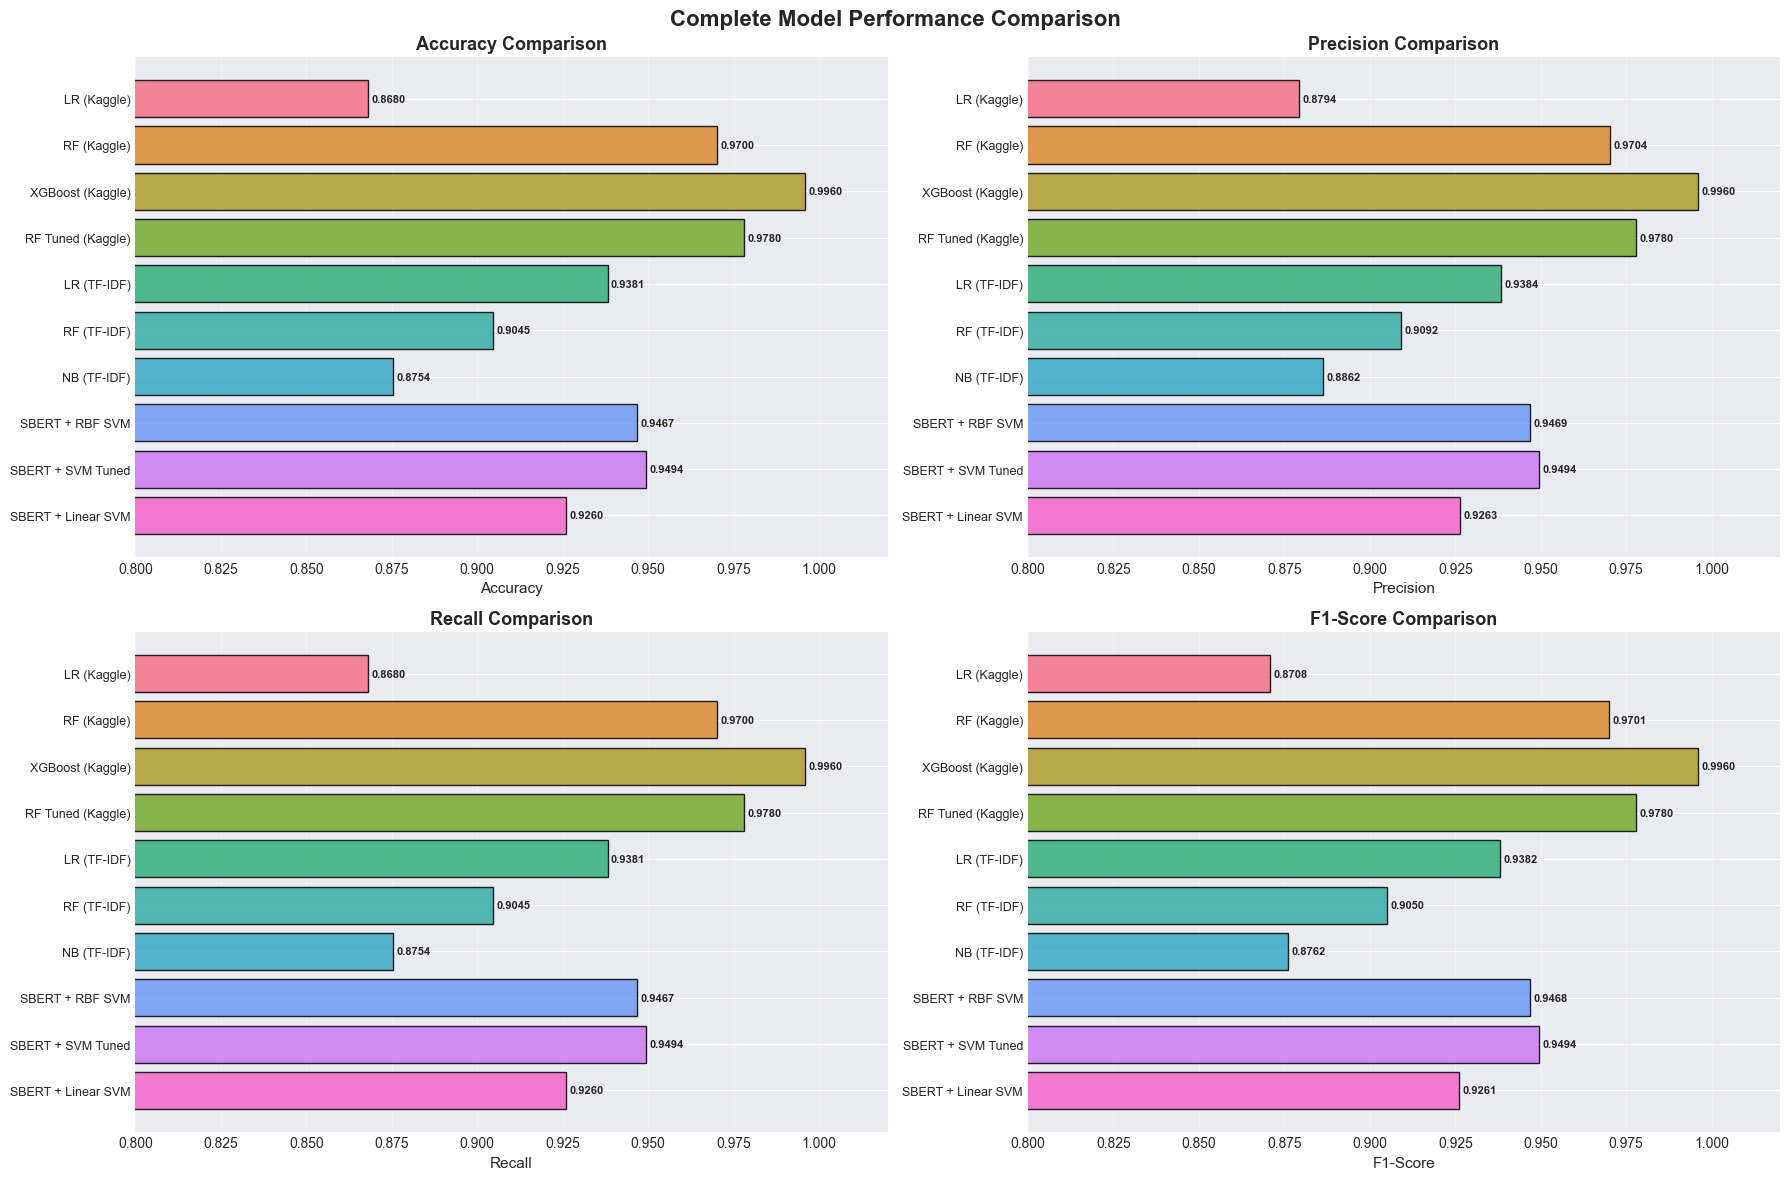

✅ Saved: ../reports/complete_model_comparison.png


In [4]:
# Cell 4: Visual Model Comparison (Bar Chart)
print("="*70)
print(" " * 20 + "MODEL COMPARISON VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Complete Model Performance Comparison', fontsize=16, fontweight='bold')

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors    = sns.color_palette("husl", len(master_df))
positions = range(len(master_df))

for ax, metric in zip(axes.flatten(), metrics):
    vals = master_df[metric].tolist()
    bars = ax.barh(positions, vals, color=colors, edgecolor='black', alpha=0.85)
    ax.set_yticks(positions)
    ax.set_yticklabels(master_df['Model'], fontsize=9)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_xlim(0.8, 1.02)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/complete_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/complete_model_comparison.png")

                    ROC CURVES - ALL MODELS


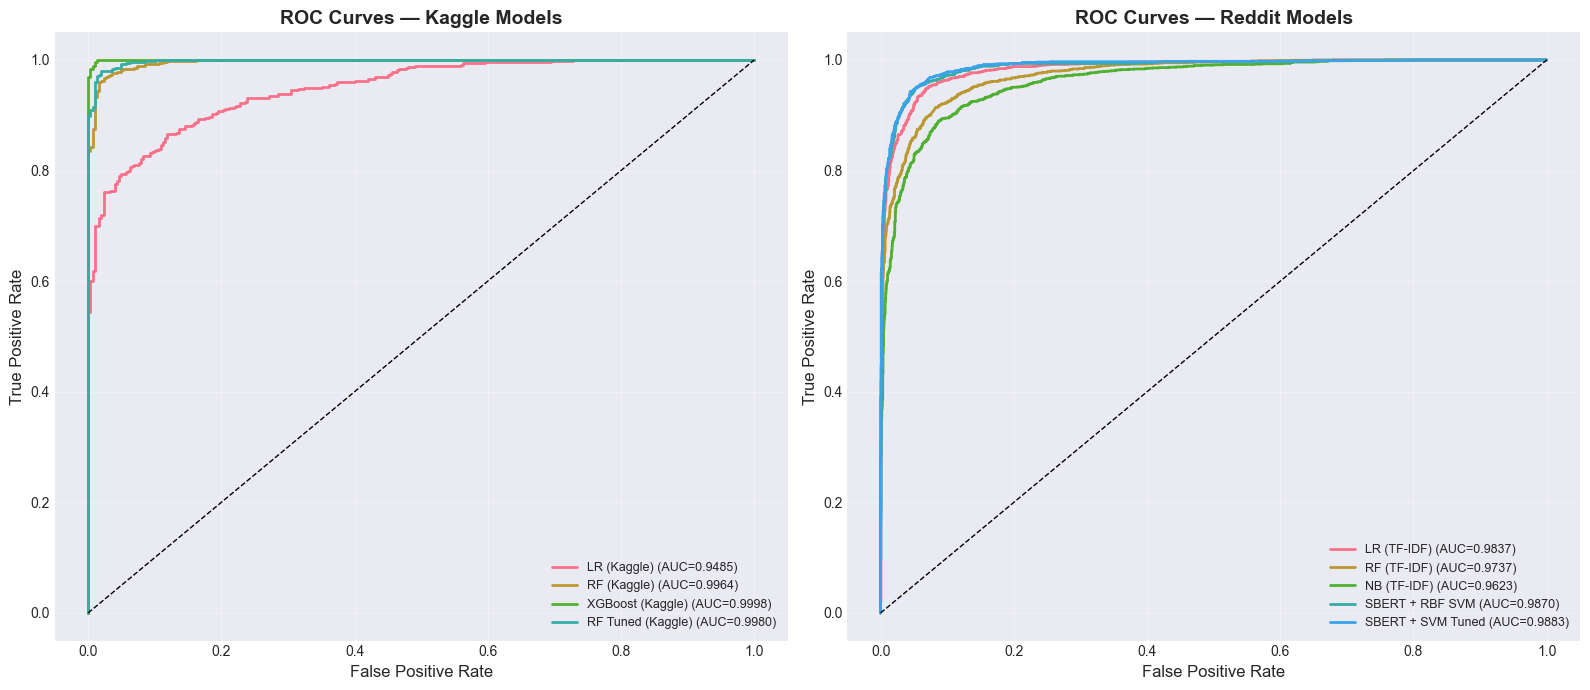

✅ Saved: ../reports/all_roc_curves.png


In [5]:
# Cell 5: ROC Curves for All Models (that support predict_proba)
print("="*70)
print(" " * 20 + "ROC CURVES - ALL MODELS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Kaggle models ──
kaggle_models = [
    (lr_model,  X_test_kg_scaled,  y_test_kg, 'LR (Kaggle)'),
    (rf_model,  X_test_kg_scaled,  y_test_kg, 'RF (Kaggle)'),
    (xgb_model, X_test_kg_scaled,  y_test_kg, 'XGBoost (Kaggle)'),
    (rf_tuned,  X_test_kg_scaled,  y_test_kg, 'RF Tuned (Kaggle)'),
]
for model, X, y, name in kaggle_models:
    fpr, tpr, _ = roc_curve(y, model.predict_proba(X)[:,1])
    auc = roc_auc_score(y, model.predict_proba(X)[:,1])
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves — Kaggle Models', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Reddit models (with proba) ──
reddit_models = [
    (lr_tfidf,  X_test_tfidf,  y_test_text, 'LR (TF-IDF)'),
    (rf_tfidf,  X_test_tfidf,  y_test_text, 'RF (TF-IDF)'),
    (nb_tfidf,  X_test_tfidf,  y_test_text, 'NB (TF-IDF)'),
    (svm_rbf,   X_test_sbert,  y_test_text, 'SBERT + RBF SVM'),
    (svm_tuned, X_test_sbert,  y_test_text, 'SBERT + SVM Tuned'),
]
for model, X, y, name in reddit_models:
    fpr, tpr, _ = roc_curve(y, model.predict_proba(X)[:,1])
    auc = roc_auc_score(y, model.predict_proba(X)[:,1])
    axes[1].plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.4f})')

axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves — Reddit Models', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/all_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/all_roc_curves.png")

In [6]:
# Cell 6: SHAP Analysis — XGBoost [FINAL WORKING VERSION v3]
print("="*70)
print(" " * 20 + "SHAP ANALYSIS — XGBoost (KernelExplainer)")
print("="*70)

import shap
import numpy as np

X_test_kg_df = pd.DataFrame(X_test_kg_scaled, columns=feature_cols)

print("\n✅ Setting up KernelExplainer...")
background = shap.sample(X_test_kg_df, 100, random_state=42)

explainer_xgb = shap.KernelExplainer(
    xgb_model.predict_proba,
    background
)

print("✅ Computing SHAP values (200 samples, ~1-2 min)...")
shap_values_raw = explainer_xgb.shap_values(X_test_kg_df[:200])

# ── Detect output format and reshape accordingly ──
print(f"\n✅ Raw output type : {type(shap_values_raw)}")

if isinstance(shap_values_raw, list):
    first = shap_values_raw[0]
    print(f"   List length      : {len(shap_values_raw)}")
    print(f"   First element    : {np.array(first).shape}")

    if len(shap_values_raw) == 2:
        # Standard format: [class0(200,14), class1(200,14)]
        shap_values_xgb = np.array(shap_values_raw[1])
        print("   Format detected  : Standard [class0, class1]")

    elif len(shap_values_raw) == 200:
        # Per-sample format: list of 200 arrays each (14, 2)
        # Stack → (200, 14, 2), then take class 1 → (200, 14)
        stacked = np.array(shap_values_raw)          # (200, 14, 2)
        shap_values_xgb = stacked[:, :, 1]           # (200, 14) — High Risk
        print("   Format detected  : Per-sample list, stacked and sliced")

    else:
        # Unknown list format — try stacking
        stacked = np.array(shap_values_raw)
        print(f"   Unknown list format, stacked shape: {stacked.shape}")
        if stacked.ndim == 3:
            shap_values_xgb = stacked[:, :, 1]
        else:
            shap_values_xgb = stacked

elif isinstance(shap_values_raw, np.ndarray):
    print(f"   Array shape      : {shap_values_raw.shape}")
    if shap_values_raw.ndim == 3:
        shap_values_xgb = shap_values_raw[:, :, 1]
    else:
        shap_values_xgb = shap_values_raw
else:
    shap_values_xgb = np.array(shap_values_raw)

print(f"\n✅ Final SHAP shape  : {shap_values_xgb.shape}  ← should be (200, 14)")
assert shap_values_xgb.shape == (200, 14), \
    f"Still wrong shape: {shap_values_xgb.shape}"
print("✅ Shape assertion passed!")

# ── Expected value ──
ev = explainer_xgb.expected_value
if isinstance(ev, (list, np.ndarray)):
    expected_value_for_waterfall = float(np.array(ev).flat[1])
else:
    expected_value_for_waterfall = float(ev)
print(f"   Base rate (expected value): {expected_value_for_waterfall:.4f}")

# ── Feature importance preview ──
mean_shap = np.abs(shap_values_xgb).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature'  : feature_cols,
    'Mean_SHAP': mean_shap
}).sort_values('Mean_SHAP', ascending=False)

print("\n✅ SHAP Feature Importance Preview:")
print(shap_importance.to_string(index=False))

                    SHAP ANALYSIS — XGBoost (KernelExplainer)

✅ Setting up KernelExplainer...
✅ Computing SHAP values (200 samples, ~1-2 min)...


100%|██████████| 200/200 [00:30<00:00,  6.48it/s]


✅ Raw output type : <class 'numpy.ndarray'>
   Array shape      : (200, 14, 2)

✅ Final SHAP shape  : (200, 14)  ← should be (200, 14)
✅ Shape assertion passed!
   Base rate (expected value): 0.6391

✅ SHAP Feature Importance Preview:
             Feature  Mean_SHAP
                 bmi   0.206119
                 age   0.172637
     lifestyle_score   0.092137
sugar_intake_encoded   0.067745
               sleep   0.062499
    exercise_encoded   0.044315
       substance_use   0.041758
       sleep_quality   0.036393
     smoking_encoded   0.026009
           age_group   0.023711
              weight   0.005652
     alcohol_encoded   0.004227
              height   0.001085
     married_encoded   0.000000


                    SHAP SUMMARY PLOT


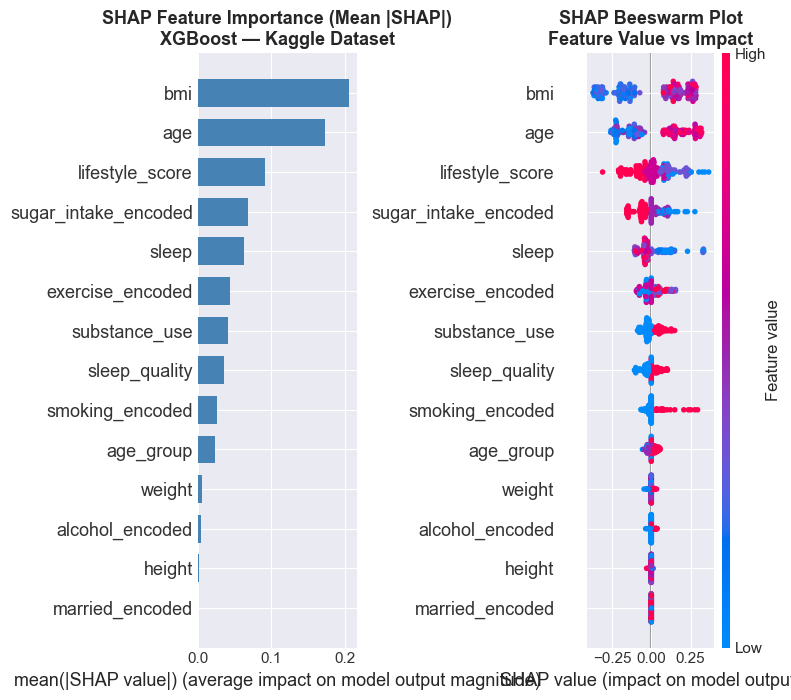

✅ Saved: ../reports/shap_xgb_summary.png

✅ SHAP Feature Importance Ranking:
             Feature  Mean_SHAP
                 bmi   0.206119
                 age   0.172637
     lifestyle_score   0.092137
sugar_intake_encoded   0.067745
               sleep   0.062499
    exercise_encoded   0.044315
       substance_use   0.041758
       sleep_quality   0.036393
     smoking_encoded   0.026009
           age_group   0.023711
              weight   0.005652
     alcohol_encoded   0.004227
              height   0.001085
     married_encoded   0.000000


In [7]:
# Cell 7: SHAP Summary Plot
print("="*70)
print(" " * 20 + "SHAP SUMMARY PLOT")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Bar plot (mean |SHAP|) ──
plt.sca(axes[0])
shap.summary_plot(
    shap_values_xgb,
    X_test_kg_df[:200],
    plot_type='bar',
    feature_names=feature_cols,
    show=False,
    max_display=14,
    color='steelblue'
)
axes[0].set_title('SHAP Feature Importance (Mean |SHAP|)\nXGBoost — Kaggle Dataset',
                  fontsize=13, fontweight='bold')

# ── Beeswarm plot ──
plt.sca(axes[1])
shap.summary_plot(
    shap_values_xgb,
    X_test_kg_df[:200],
    feature_names=feature_cols,
    show=False,
    max_display=14
)
axes[1].set_title('SHAP Beeswarm Plot\nFeature Value vs Impact',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/shap_xgb_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/shap_xgb_summary.png")

print("\n✅ SHAP Feature Importance Ranking:")
print(shap_importance.to_string(index=False))

                    SHAP WATERFALL PLOTS — INDIVIDUAL PREDICTIONS


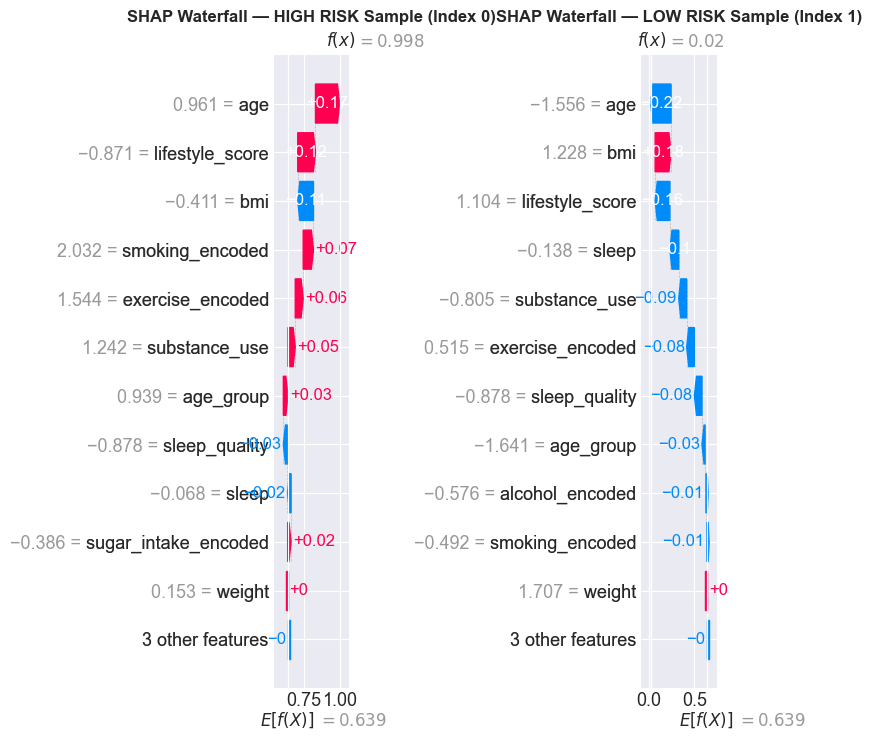

✅ Saved: ../reports/shap_waterfall_plots.png

✅ HIGH RISK sample (idx=0):
   age                      : value=  0.96  SHAP=+0.1669
   weight                   : value=  0.15  SHAP=+0.0000
   height                   : value=  0.82  SHAP=+0.0000
   sleep                    : value= -0.07  SHAP=-0.0249
   bmi                      : value= -0.41  SHAP=-0.1088
   exercise_encoded         : value=  1.54  SHAP=+0.0550
   sugar_intake_encoded     : value= -0.39  SHAP=+0.0235
   smoking_encoded          : value=  2.03  SHAP=+0.0711
   alcohol_encoded          : value= -0.58  SHAP=+0.0000
   married_encoded          : value=  0.81  SHAP=+0.0000
   age_group                : value=  0.94  SHAP=+0.0321
   sleep_quality            : value= -0.88  SHAP=-0.0286
   substance_use            : value=  1.24  SHAP=+0.0502
   lifestyle_score          : value= -0.87  SHAP=+0.1228

✅ LOW RISK sample (idx=1):
   age                      : value= -1.56  SHAP=-0.2242
   weight                   : value=  1.71 

In [8]:
# Cell 8: SHAP Waterfall Plots — Individual Predictions
print("="*70)
print(" " * 20 + "SHAP WATERFALL PLOTS — INDIVIDUAL PREDICTIONS")
print("="*70)

# Use first 200 samples (matching shap_values_xgb)
X_test_200      = X_test_kg_df[:200]
y_test_200      = y_test_kg.values[:200]

high_risk_idx = np.where(y_test_200 == 1)[0][0]
low_risk_idx  = np.where(y_test_200 == 0)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, idx, label in [(axes[0], high_risk_idx, 'HIGH RISK'),
                        (axes[1], low_risk_idx,  'LOW RISK')]:
    plt.sca(ax)
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values_xgb[idx],
            base_values   = expected_value_for_waterfall,
            data          = X_test_200.iloc[idx].values,
            feature_names = feature_cols
        ),
        show=False,
        max_display=12
    )
    ax.set_title(f'SHAP Waterfall — {label} Sample (Index {idx})',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/shap_waterfall_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/shap_waterfall_plots.png")

print(f"\n✅ HIGH RISK sample (idx={high_risk_idx}):")
for feat, val, sv in zip(feature_cols,
                          X_test_200.iloc[high_risk_idx].values,
                          shap_values_xgb[high_risk_idx]):
    print(f"   {feat:25s}: value={val:6.2f}  SHAP={sv:+.4f}")

print(f"\n✅ LOW RISK sample (idx={low_risk_idx}):")
for feat, val, sv in zip(feature_cols,
                          X_test_200.iloc[low_risk_idx].values,
                          shap_values_xgb[low_risk_idx]):
    print(f"   {feat:25s}: value={val:6.2f}  SHAP={sv:+.4f}")

                    SHAP DEPENDENCE PLOTS


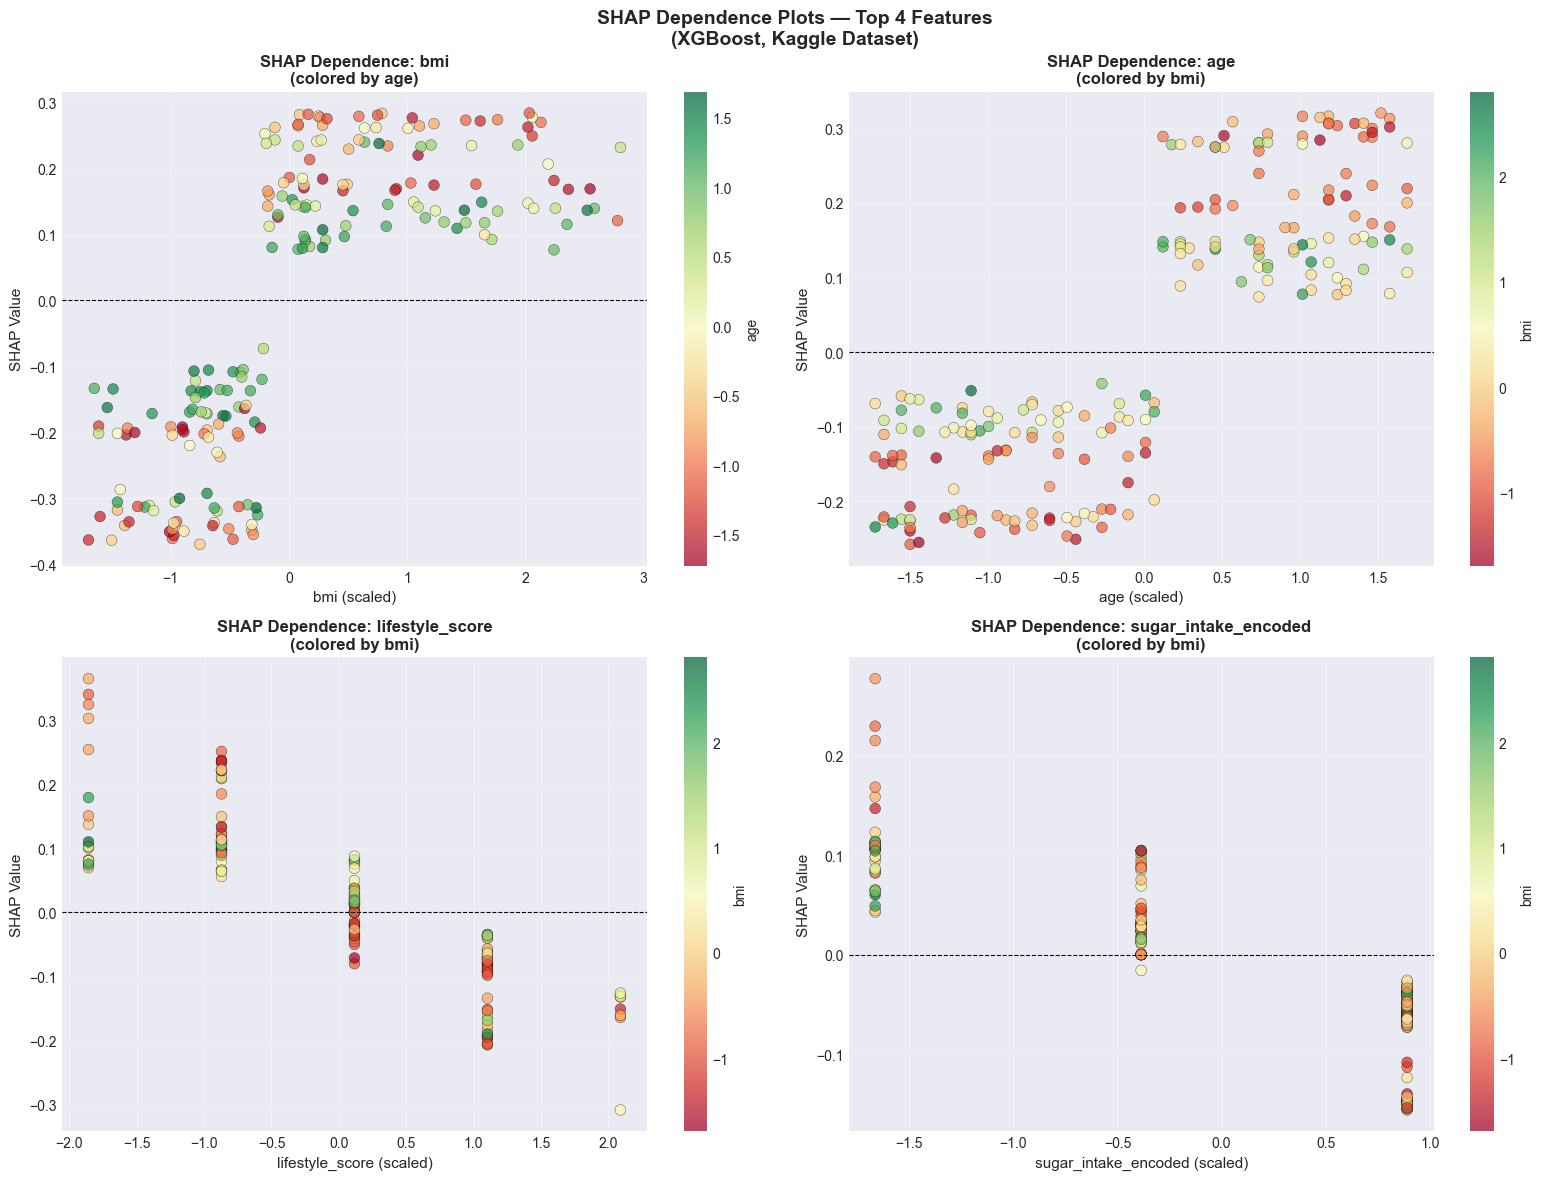

✅ Saved: ../reports/shap_dependence_plots.png


In [9]:
# Cell 9: SHAP Dependence Plots — Top 4 Features
print("="*70)
print(" " * 20 + "SHAP DEPENDENCE PLOTS")
print("="*70)

X_test_200 = X_test_kg_df[:200]
top_4_features = shap_importance['Feature'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, feat in zip(axes.flatten(), top_4_features):
    feat_idx = feature_cols.index(feat)

    x_vals  = X_test_200.iloc[:, feat_idx].values
    s_vals  = shap_values_xgb[:, feat_idx]

    # Color by the interacting feature (second most correlated)
    other_feats = [f for f in top_4_features if f != feat]
    color_feat  = other_feats[0]
    color_idx   = feature_cols.index(color_feat)
    color_vals  = X_test_200.iloc[:, color_idx].values

    sc = ax.scatter(x_vals, s_vals,
                    c=color_vals, cmap='RdYlGn',
                    alpha=0.7, edgecolors='black',
                    linewidth=0.3, s=60)
    plt.colorbar(sc, ax=ax, label=color_feat)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel(f'{feat} (scaled)', fontsize=11)
    ax.set_ylabel('SHAP Value', fontsize=11)
    ax.set_title(f'SHAP Dependence: {feat}\n(colored by {color_feat})',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('SHAP Dependence Plots — Top 4 Features\n(XGBoost, Kaggle Dataset)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_dependence_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/shap_dependence_plots.png")

                    SHAP ANALYSIS — RANDOM FOREST

✅ Computing SHAP values for Random Forest Tuned...
   Raw shape: (200, 14, 2)
✅ RF SHAP shape after fix: (200, 14)  ← should be (200, 14)
✅ Shape assertion passed!


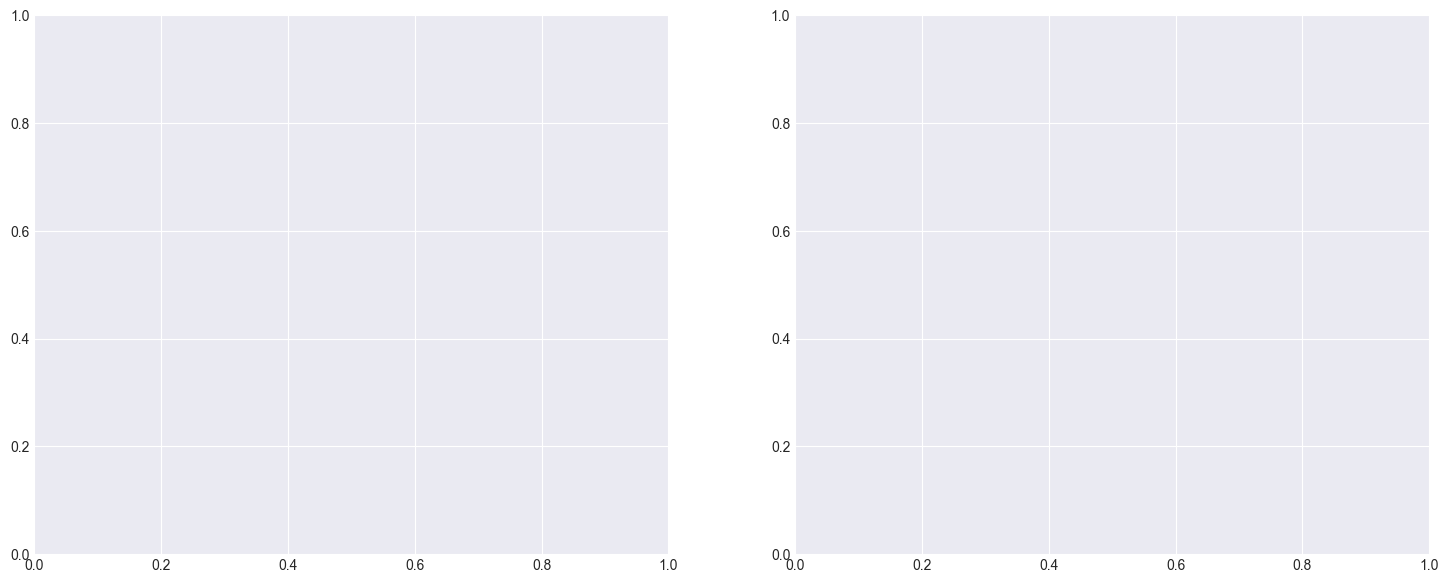

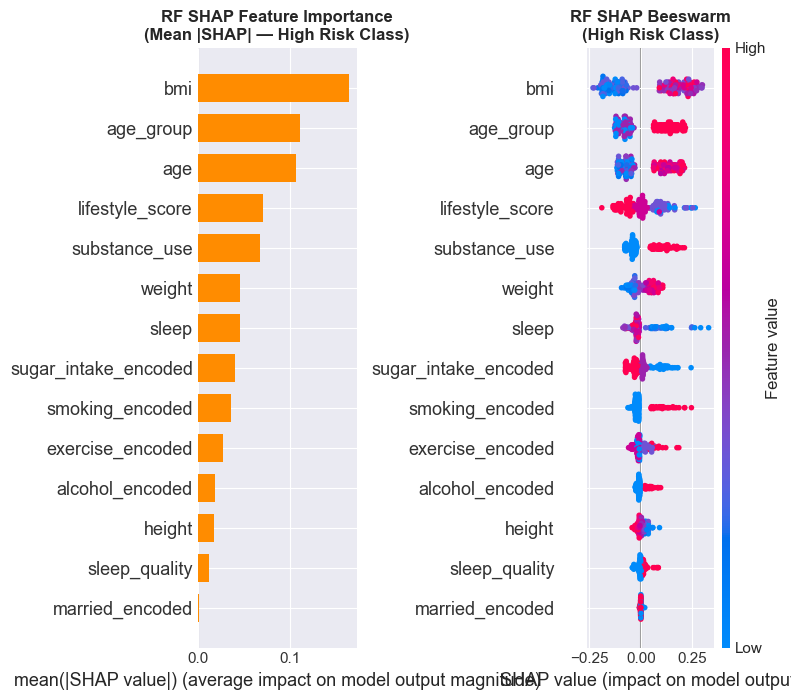

✅ Saved: ../reports/shap_rf_summary.png

✅ XGBoost vs Random Forest — SHAP Comparison:
             Feature  XGBoost_SHAP  RF_SHAP
                 bmi      0.206119 0.163842
                 age      0.172637 0.106181
     lifestyle_score      0.092137 0.070295
sugar_intake_encoded      0.067745 0.040849
               sleep      0.062499 0.045756
    exercise_encoded      0.044315 0.027076
       substance_use      0.041758 0.066993
       sleep_quality      0.036393 0.011822
     smoking_encoded      0.026009 0.036431
           age_group      0.023711 0.110730
              weight      0.005652 0.046090
     alcohol_encoded      0.004227 0.018928
              height      0.001085 0.017607
     married_encoded      0.000000 0.001875


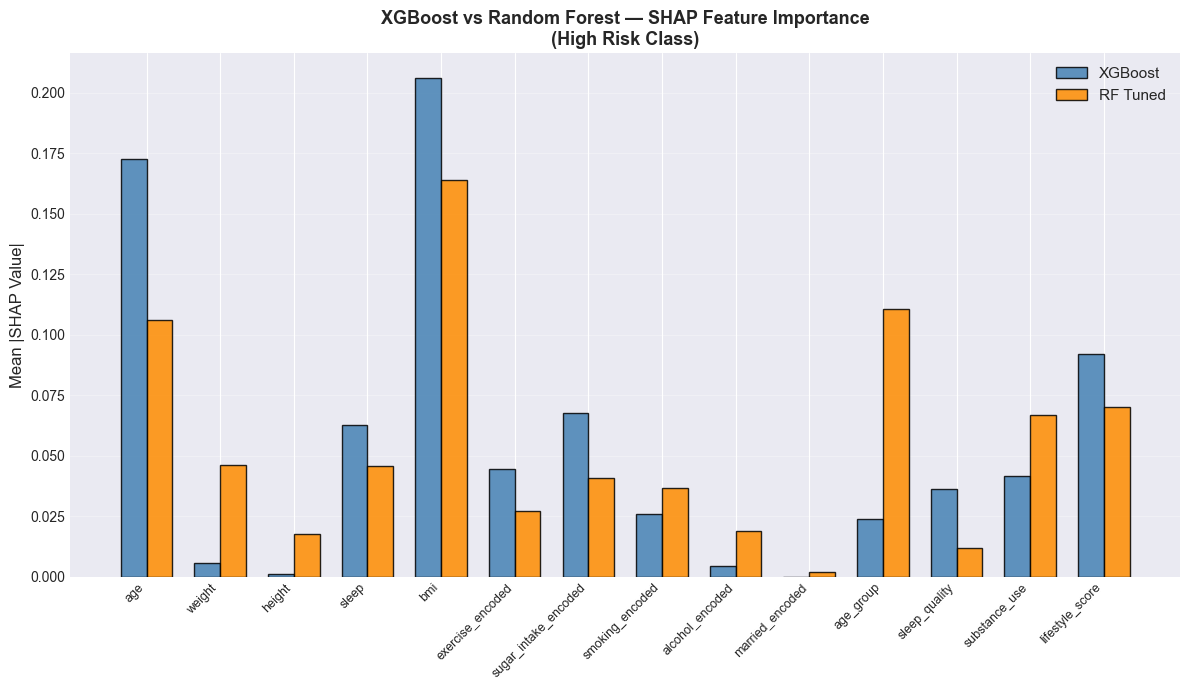

✅ Saved: ../reports/shap_xgb_vs_rf_comparison.png

✅ Key Insights:
   Top 3 features both models agree on : ['bmi', 'age']
   → These are the most robust predictors of health risk


In [12]:
# Cell 10: SHAP for Random Forest — Summary [FIXED]
print("="*70)
print(" " * 20 + "SHAP ANALYSIS — RANDOM FOREST")
print("="*70)

print("\n✅ Computing SHAP values for Random Forest Tuned...")
explainer_rf    = shap.TreeExplainer(rf_tuned)
shap_values_rf_raw = explainer_rf.shap_values(X_test_200)

# ── Detect and fix shape (same issue as XGBoost) ──
raw = np.array(shap_values_rf_raw)
print(f"   Raw shape: {raw.shape}")

if raw.ndim == 3 and raw.shape == (200, 14, 2):
    # (200, 14, 2) → take class 1
    shap_vals_rf_class1 = raw[:, :, 1]
elif raw.ndim == 3 and raw.shape == (2, 200, 14):
    # Standard format [class0, class1]
    shap_vals_rf_class1 = raw[1]
elif raw.ndim == 2 and raw.shape == (14, 2):
    # Per-sample collapsed — need to recompute per sample
    stacked = np.array([explainer_rf.shap_values(
        X_test_200.iloc[i:i+1]
    ) for i in range(len(X_test_200))])
    shap_vals_rf_class1 = stacked[:, :, 1].squeeze()
else:
    # Fallback: try taking index 1
    shap_vals_rf_class1 = raw[1] if raw.shape[0] == 2 else raw[:, :, 1]

print(f"✅ RF SHAP shape after fix: {shap_vals_rf_class1.shape}  ← should be (200, 14)")
assert shap_vals_rf_class1.shape == (200, 14), \
    f"Shape mismatch: {shap_vals_rf_class1.shape}"
print("✅ Shape assertion passed!")

# ── Summary plots ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_vals_rf_class1, X_test_200,
                  feature_names=feature_cols,
                  plot_type='bar', show=False,
                  max_display=14, color='darkorange')
axes[0].set_title('RF SHAP Feature Importance\n(Mean |SHAP| — High Risk Class)',
                  fontsize=12, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_vals_rf_class1, X_test_200,
                  feature_names=feature_cols,
                  show=False, max_display=14)
axes[1].set_title('RF SHAP Beeswarm\n(High Risk Class)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/shap_rf_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/shap_rf_summary.png")

# ── XGBoost vs RF comparison ──
rf_mean_shap  = np.abs(shap_vals_rf_class1).mean(axis=0)
xgb_mean_shap = np.abs(shap_values_xgb).mean(axis=0)

comparison_df = pd.DataFrame({
    'Feature'      : feature_cols,
    'XGBoost_SHAP' : xgb_mean_shap,
    'RF_SHAP'      : rf_mean_shap
}).sort_values('XGBoost_SHAP', ascending=False)

print("\n✅ XGBoost vs Random Forest — SHAP Comparison:")
print(comparison_df.to_string(index=False))

# ── Visual comparison ──
fig, ax = plt.subplots(figsize=(12, 7))
x      = np.arange(len(feature_cols))
width  = 0.35
bars1  = ax.bar(x - width/2, xgb_mean_shap, width,
                label='XGBoost', color='steelblue',  edgecolor='black', alpha=0.85)
bars2  = ax.bar(x + width/2, rf_mean_shap,  width,
                label='RF Tuned', color='darkorange', edgecolor='black', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP Value|', fontsize=12)
ax.set_title('XGBoost vs Random Forest — SHAP Feature Importance\n(High Risk Class)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../reports/shap_xgb_vs_rf_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/shap_xgb_vs_rf_comparison.png")

print("\n✅ Key Insights:")
# Find features that agree and disagree between models
xgb_rank = comparison_df['Feature'].tolist()
rf_rank  = comparison_df.sort_values('RF_SHAP', ascending=False)['Feature'].tolist()
top3_agree = [f for f in xgb_rank[:3] if f in rf_rank[:3]]
print(f"   Top 3 features both models agree on : {top3_agree}")
print(f"   → These are the most robust predictors of health risk")

In [13]:
# Cell 11: LIME Setup for TF-IDF Models
print("="*70)
print(" " * 20 + "LIME ANALYSIS — SETUP")
print("="*70)

import lime
import lime.lime_text

# Rebuild text train/test split (needed for LIME)
from sklearn.model_selection import train_test_split

X_reddit_text = df_reddit['cleaned_text'].values
y_reddit      = df_reddit['risk_label'].values

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_reddit_text, y_reddit,
    test_size=0.2,
    stratify=y_reddit,
    random_state=42
)

print(f"✅ Text data ready:")
print(f"   Train: {len(X_train_text):,} samples")
print(f"   Test : {len(X_test_text):,} samples")

# ── Create LIME explainer ──
lime_explainer = lime.lime_text.LimeTextExplainer(
    class_names=['Low Risk', 'High Risk'],
    random_state=42
)

# ── Prediction wrapper for LIME ──
def predict_fn_tfidf(texts):
    X = tfidf_vec.transform(texts)
    return lr_tfidf.predict_proba(X)

# ── Quick sanity check ──
sample_probs = predict_fn_tfidf([X_test_text[0]])
print(f"\n✅ LIME prediction function verified:")
print(f"   Sample text     : '{X_test_text[0][:80]}...'")
print(f"   Low Risk prob   : {sample_probs[0][0]:.4f}")
print(f"   High Risk prob  : {sample_probs[0][1]:.4f}")
print(f"   Predicted class : {'HIGH RISK' if sample_probs[0][1] >= 0.5 else 'LOW RISK'}")

print(f"\n✅ LIME explainer ready!")
print(f"   Classes: {lime_explainer.class_names}")
print(f"   Model  : TF-IDF + Logistic Regression")

                    LIME ANALYSIS — SETUP
✅ Text data ready:
   Train: 15,248 samples
   Test : 3,812 samples

✅ LIME prediction function verified:
   Sample text     : 'person typically followed could improve improve iron level iron tablet fruit gla...'
   Low Risk prob   : 0.8462
   High Risk prob  : 0.1538
   Predicted class : LOW RISK

✅ LIME explainer ready!
   Classes: ['Low Risk', 'High Risk']
   Model  : TF-IDF + Logistic Regression


                    LIME EXPLANATION — HIGH RISK POST

✅ Selected HIGH RISK post:
   Index            : 2906
   True Label       : HIGH RISK
   Predicted Prob   : 0.9991
   Text Preview     : 'diagnosed type diabetes day ago glucose level doctor want use insulin i’m scared anxious...'

✅ Generating LIME explanation (this takes ~20 seconds)...


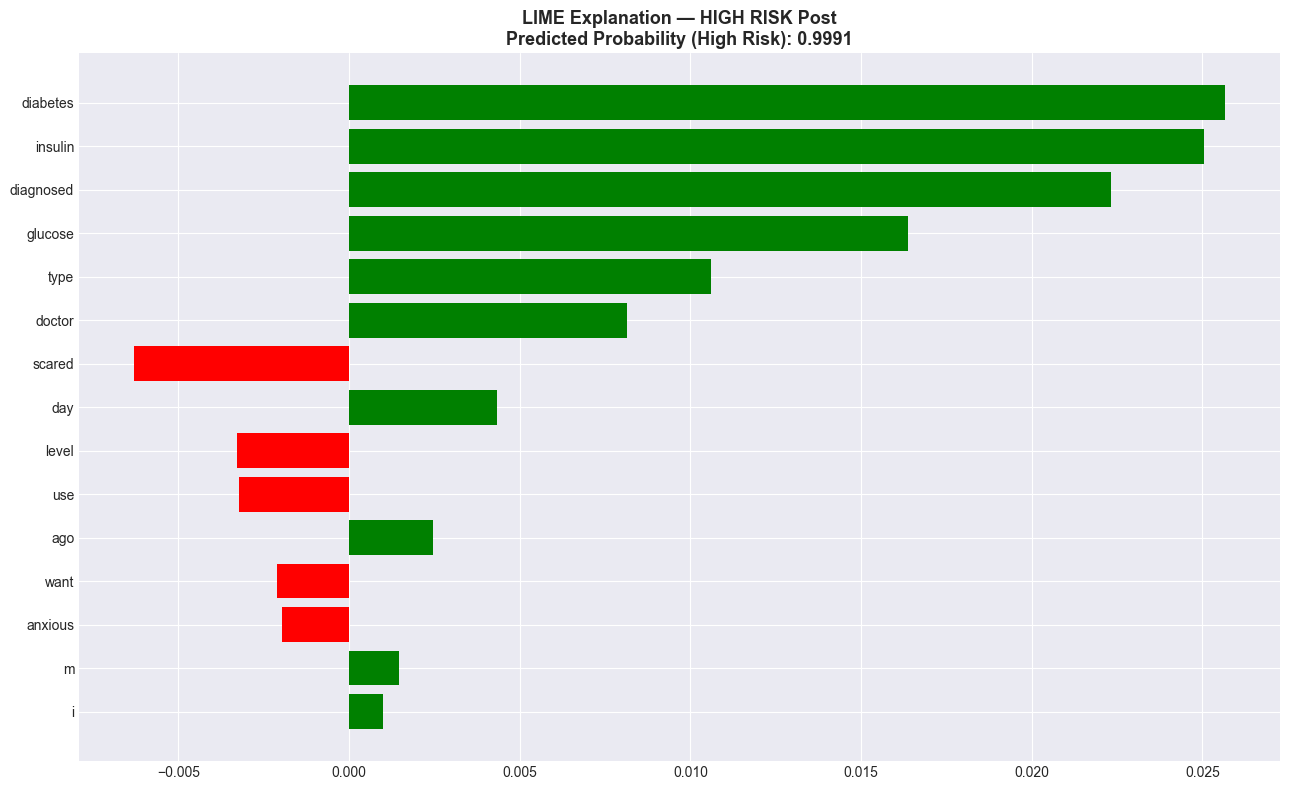

✅ Saved: ../reports/lime_high_risk_explanation.png

✅ Word Contributions (High Risk Post):
   Word                          Weight  Direction
   --------------------------------------------------
   diabetes                     +0.0257  → HIGH RISK 🔴
   insulin                      +0.0251  → HIGH RISK 🔴
   diagnosed                    +0.0223  → HIGH RISK 🔴
   glucose                      +0.0164  → HIGH RISK 🔴
   type                         +0.0106  → HIGH RISK 🔴
   doctor                       +0.0081  → HIGH RISK 🔴
   scared                       -0.0063  → LOW RISK  🟢
   day                          +0.0043  → HIGH RISK 🔴
   level                        -0.0033  → LOW RISK  🟢
   use                          -0.0032  → LOW RISK  🟢
   ago                          +0.0025  → HIGH RISK 🔴
   want                         -0.0021  → LOW RISK  🟢
   anxious                      -0.0020  → LOW RISK  🟢
   m                            +0.0015  → HIGH RISK 🔴
   i                            +0

In [14]:
# Cell 12: LIME Explanation — High Risk Post
print("="*70)
print(" " * 20 + "LIME EXPLANATION — HIGH RISK POST")
print("="*70)

# ── Find highest confidence high-risk post ──
hr_indices = np.where(y_test_text == 1)[0]
X_hr       = tfidf_vec.transform(X_test_text[hr_indices])
probs_hr   = lr_tfidf.predict_proba(X_hr)[:, 1]

best_local = np.argmax(probs_hr)
hr_idx     = hr_indices[best_local]
hr_text    = X_test_text[hr_idx]
hr_prob    = probs_hr[best_local]

print(f"\n✅ Selected HIGH RISK post:")
print(f"   Index            : {hr_idx}")
print(f"   True Label       : HIGH RISK")
print(f"   Predicted Prob   : {hr_prob:.4f}")
print(f"   Text Preview     : '{hr_text[:200]}...'")

# ── Generate LIME explanation ──
print("\n✅ Generating LIME explanation (this takes ~20 seconds)...")
exp_hr = lime_explainer.explain_instance(
    hr_text,
    predict_fn_tfidf,
    num_features=15,
    num_samples=1000
)

# ── Plot ──
fig = exp_hr.as_pyplot_figure()
fig.set_size_inches(13, 8)
plt.title(
    f'LIME Explanation — HIGH RISK Post\n'
    f'Predicted Probability (High Risk): {hr_prob:.4f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/lime_high_risk_explanation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/lime_high_risk_explanation.png")

# ── Print word contributions ──
print("\n✅ Word Contributions (High Risk Post):")
print(f"   {'Word':<25s} {'Weight':>10s}  Direction")
print("   " + "-"*50)
for word, weight in sorted(exp_hr.as_list(), key=lambda x: abs(x[1]), reverse=True):
    direction = "→ HIGH RISK 🔴" if weight > 0 else "→ LOW RISK  🟢"
    print(f"   {word:<25s} {weight:>+10.4f}  {direction}")

                    LIME EXPLANATION — LOW RISK POST

✅ Selected LOW RISK post:
   Index            : 1816
   True Label       : LOW RISK
   Predicted Prob   : 0.9989
   Text Preview     : 'anyone keto fasting find bit tough keto guy suggestwhat storymy goal lose weight started keto week ago goal planning extended fast...'

✅ Generating LIME explanation (this takes ~20 seconds)...


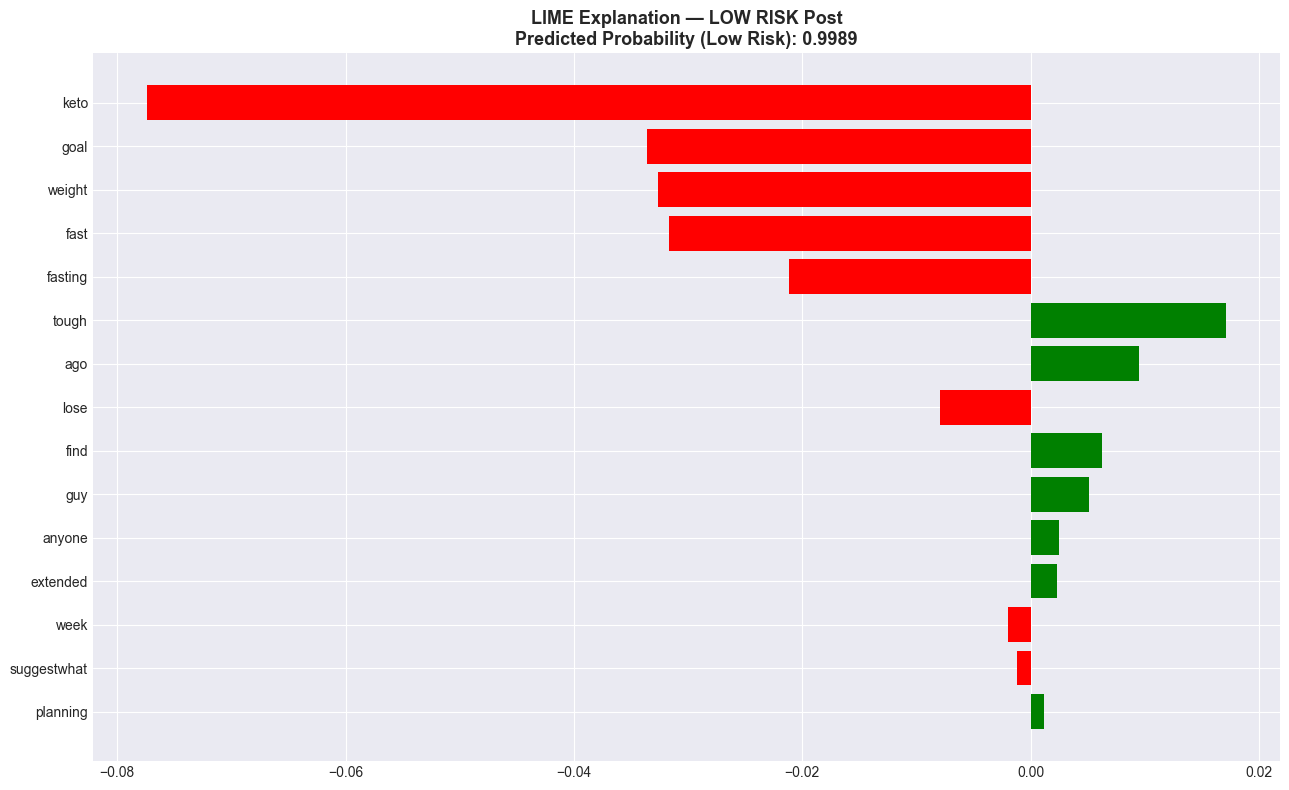

✅ Saved: ../reports/lime_low_risk_explanation.png

✅ Word Contributions (Low Risk Post):
   Word                          Weight  Direction
   --------------------------------------------------
   keto                         -0.0774  → LOW RISK  🟢
   goal                         -0.0336  → LOW RISK  🟢
   weight                       -0.0327  → LOW RISK  🟢
   fast                         -0.0317  → LOW RISK  🟢
   fasting                      -0.0212  → LOW RISK  🟢
   tough                        +0.0171  → HIGH RISK 🔴
   ago                          +0.0095  → HIGH RISK 🔴
   lose                         -0.0079  → LOW RISK  🟢
   find                         +0.0063  → HIGH RISK 🔴
   guy                          +0.0051  → HIGH RISK 🔴
   anyone                       +0.0025  → HIGH RISK 🔴
   extended                     +0.0023  → HIGH RISK 🔴
   week                         -0.0020  → LOW RISK  🟢
   suggestwhat                  -0.0012  → LOW RISK  🟢
   planning                     +0.0

In [15]:
# Cell 13: LIME Explanation — Low Risk Post
print("="*70)
print(" " * 20 + "LIME EXPLANATION — LOW RISK POST")
print("="*70)

# ── Find highest confidence low-risk post ──
lr_indices   = np.where(y_test_text == 0)[0]
X_lr         = tfidf_vec.transform(X_test_text[lr_indices])
probs_lr_val = lr_tfidf.predict_proba(X_lr)[:, 0]

best_local_lr = np.argmax(probs_lr_val)
lr_idx        = lr_indices[best_local_lr]
lr_text       = X_test_text[lr_idx]
lr_prob       = probs_lr_val[best_local_lr]

print(f"\n✅ Selected LOW RISK post:")
print(f"   Index            : {lr_idx}")
print(f"   True Label       : LOW RISK")
print(f"   Predicted Prob   : {lr_prob:.4f}")
print(f"   Text Preview     : '{lr_text[:200]}...'")

# ── Generate LIME explanation ──
print("\n✅ Generating LIME explanation (this takes ~20 seconds)...")
exp_lr_lime = lime_explainer.explain_instance(
    lr_text,
    predict_fn_tfidf,
    num_features=15,
    num_samples=1000
)

# ── Plot ──
fig = exp_lr_lime.as_pyplot_figure()
fig.set_size_inches(13, 8)
plt.title(
    f'LIME Explanation — LOW RISK Post\n'
    f'Predicted Probability (Low Risk): {lr_prob:.4f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/lime_low_risk_explanation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/lime_low_risk_explanation.png")

# ── Print word contributions ──
print("\n✅ Word Contributions (Low Risk Post):")
print(f"   {'Word':<25s} {'Weight':>10s}  Direction")
print("   " + "-"*50)
for word, weight in sorted(exp_lr_lime.as_list(), key=lambda x: abs(x[1]), reverse=True):
    direction = "→ HIGH RISK 🔴" if weight > 0 else "→ LOW RISK  🟢"
    print(f"   {word:<25s} {weight:>+10.4f}  {direction}")

# ── Side by side comparison ──
print("\n✅ HIGH RISK vs LOW RISK — Top Words Comparison:")
hr_words = {w: v for w, v in exp_hr.as_list()}
lr_words = {w: v for w, v in exp_lr_lime.as_list()}

print(f"\n   {'HIGH RISK top words':<35s}  {'LOW RISK top words':<35s}")
print("   " + "-"*70)
hr_sorted = sorted(hr_words.items(), key=lambda x: x[1], reverse=True)[:5]
lr_sorted = sorted(lr_words.items(), key=lambda x: x[1])[:5]
for (hw, hv), (lw, lv) in zip(hr_sorted, lr_sorted):
    print(f"   {hw:<25s} {hv:>+8.4f}     {lw:<25s} {lv:>+8.4f}")

                    LIME CASE STUDIES — 5 POSTS

✅ Generating LIME explanations for 5 case studies...
   (Each takes ~15 seconds — total ~75 seconds)

   Case 1/5: HIGH RISK → Predicted HIGH RISK ✅ (conf=0.931)
   Case 2/5: HIGH RISK → Predicted HIGH RISK ✅ (conf=0.547)
   Case 3/5: HIGH RISK → Predicted HIGH RISK ✅ (conf=0.966)
   Case 4/5: LOW RISK → Predicted LOW RISK ✅ (conf=0.846)
   Case 5/5: LOW RISK → Predicted LOW RISK ✅ (conf=0.989)


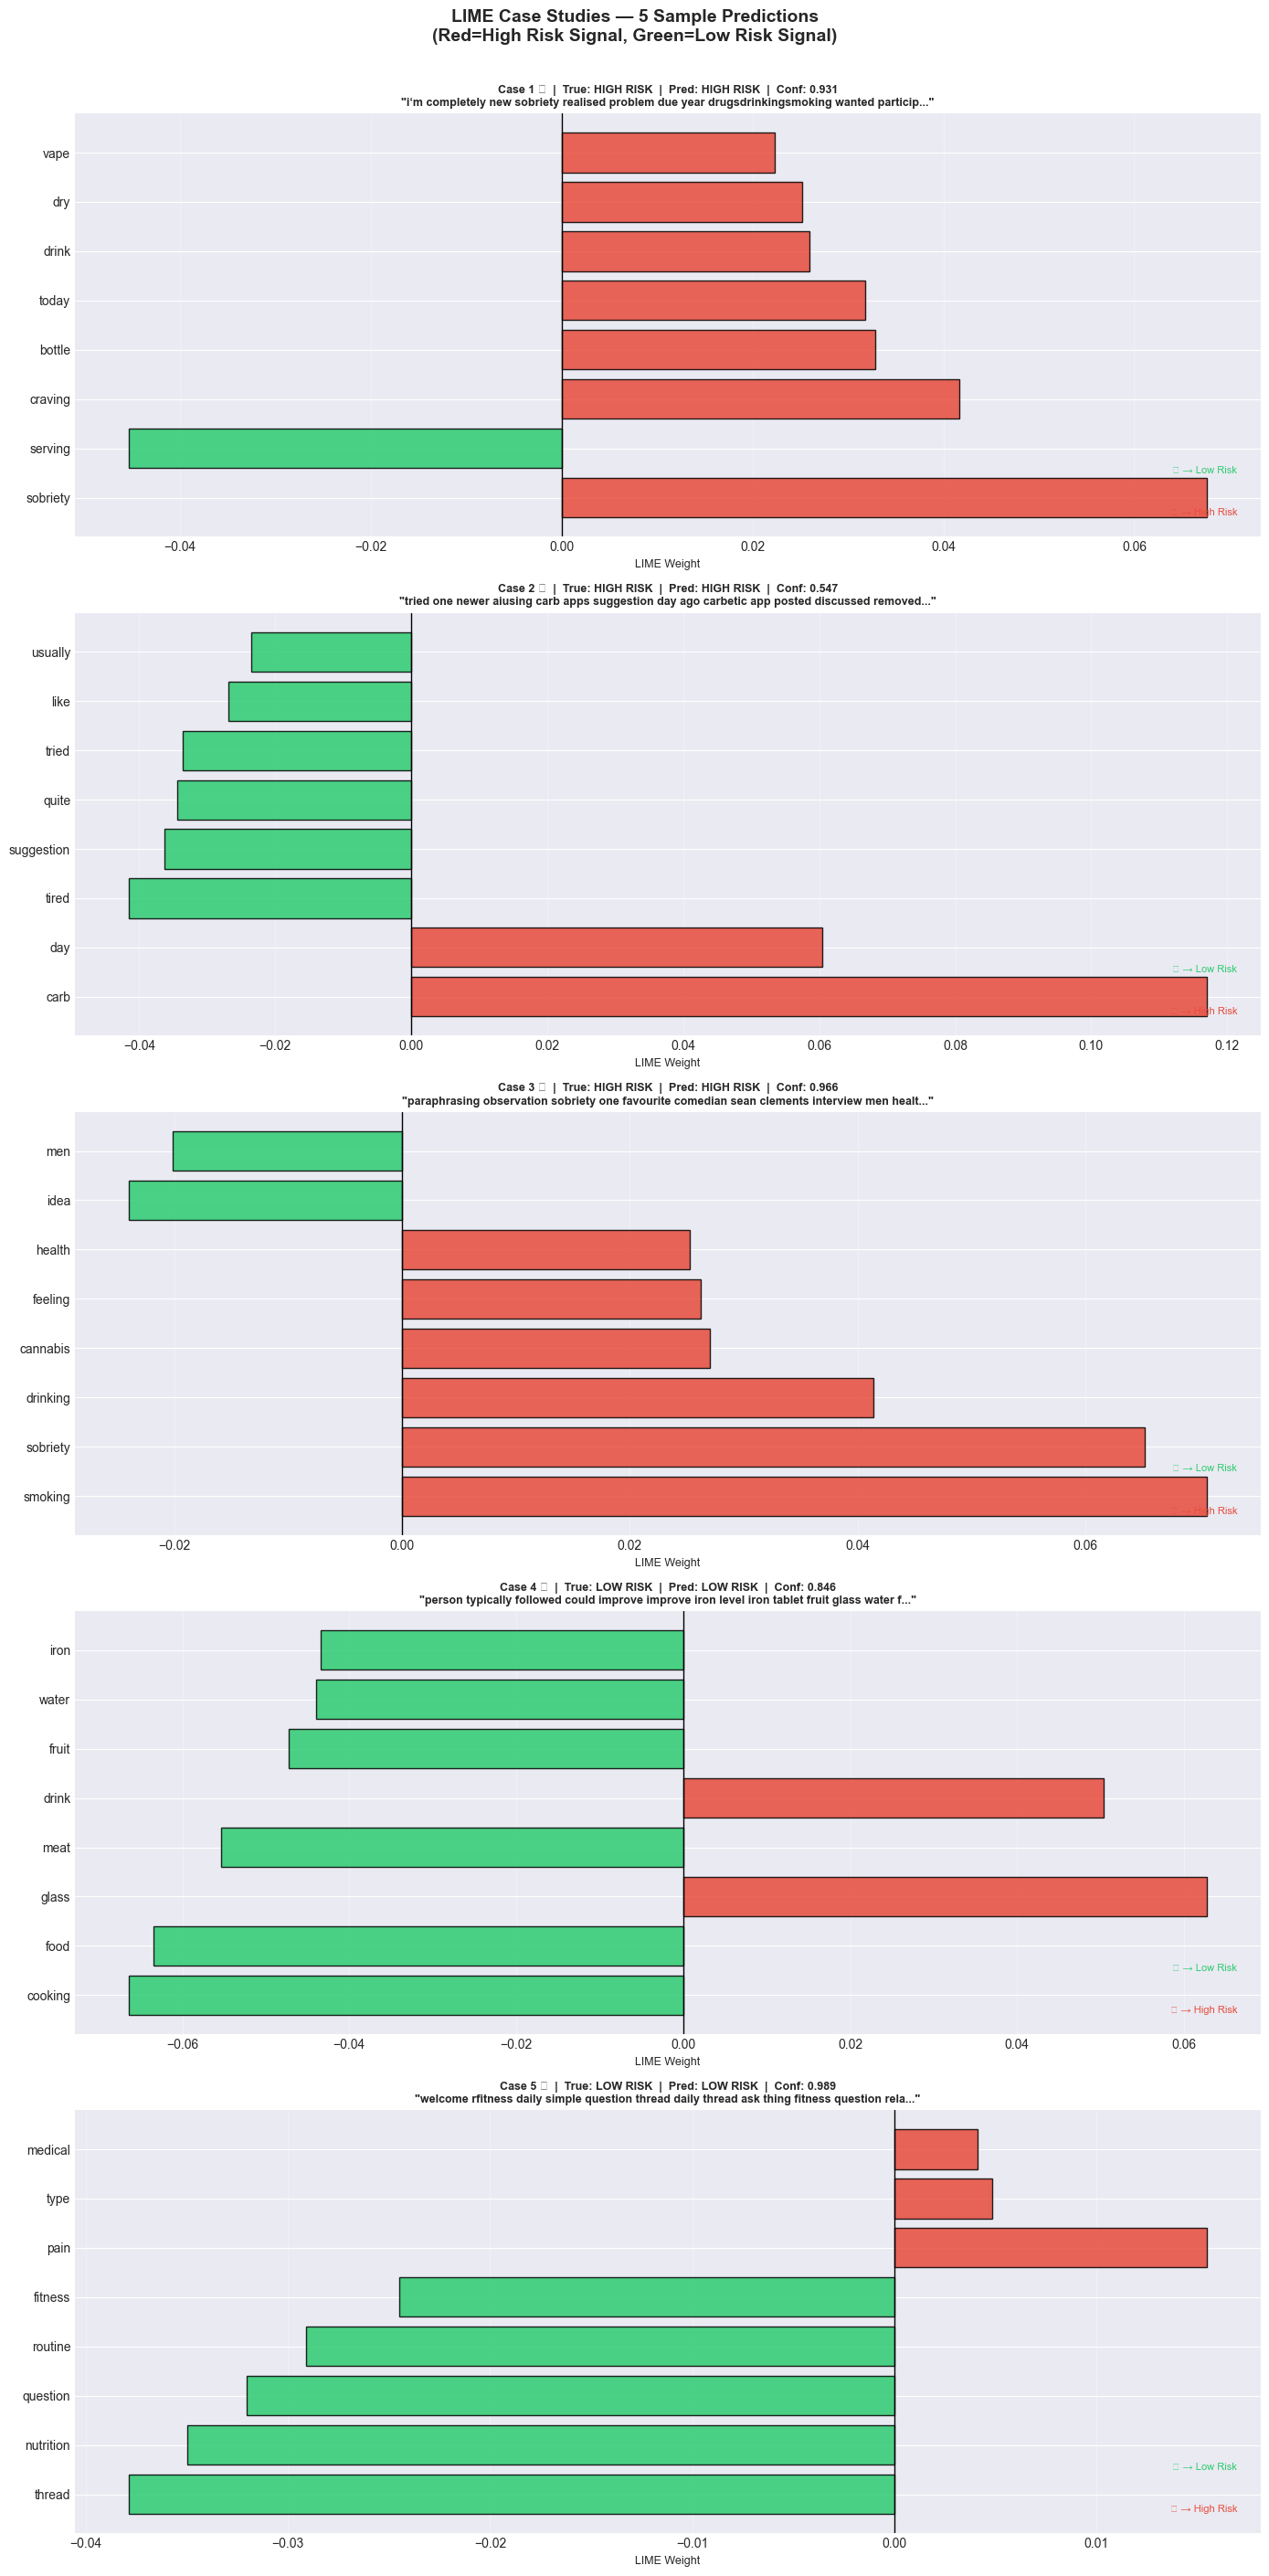


✅ Saved: ../reports/lime_case_studies.png

✅ Case Study Summary:
 Case True Label Predicted  Confidence Correct                   Top Words
    1  HIGH RISK HIGH RISK      0.9311       ✅  sobriety, serving, craving
    2  HIGH RISK HIGH RISK      0.5474       ✅            carb, day, tired
    3  HIGH RISK HIGH RISK      0.9664       ✅ smoking, sobriety, drinking
    4   LOW RISK  LOW RISK      0.8462       ✅        cooking, food, glass
    5   LOW RISK  LOW RISK      0.9892       ✅ thread, nutrition, question

✅ Accuracy on 5 cases: 5/5 (100%)


In [16]:
# Cell 14: LIME Case Studies — 5 Diverse Posts
print("="*70)
print(" " * 20 + "LIME CASE STUDIES — 5 POSTS")
print("="*70)

# ── Select 5 diverse samples ──
sample_configs = [
    (np.where(y_test_text==1)[0][0],  'HIGH RISK'),
    (np.where(y_test_text==1)[0][5],  'HIGH RISK'),
    (np.where(y_test_text==1)[0][10], 'HIGH RISK'),
    (np.where(y_test_text==0)[0][0],  'LOW RISK'),
    (np.where(y_test_text==0)[0][5],  'LOW RISK'),
]

fig, axes = plt.subplots(5, 1, figsize=(14, 28))
case_study_results = []

print("\n✅ Generating LIME explanations for 5 case studies...")
print("   (Each takes ~15 seconds — total ~75 seconds)\n")

for case_num, (ax, (idx, true_label)) in enumerate(
        zip(axes.flatten(), sample_configs), start=1):

    text  = X_test_text[idx]
    probs = predict_fn_tfidf([text])[0]
    pred  = 'HIGH RISK' if probs[1] >= 0.5 else 'LOW RISK'
    conf  = max(probs)
    correct = '✅' if pred == true_label else '❌'

    print(f"   Case {case_num}/5: {true_label} → Predicted {pred} {correct} (conf={conf:.3f})")

    # Generate explanation
    exp = lime_explainer.explain_instance(
        text,
        predict_fn_tfidf,
        num_features=8,
        num_samples=500
    )

    top_words = exp.as_list()[:8]
    vals      = [v for _, v in top_words]
    words     = [w for w, _ in top_words]
    bar_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in vals]

    ax.barh(range(len(words)), vals, color=bar_colors,
            edgecolor='black', alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('LIME Weight', fontsize=9)
    ax.set_title(
        f'Case {case_num} {correct}  |  True: {true_label}  |  '
        f'Pred: {pred}  |  Conf: {conf:.3f}\n'
        f'"{text[:90]}..."',
        fontsize=9, fontweight='bold'
    )
    ax.grid(True, alpha=0.3, axis='x')

    # Legend annotation
    ax.annotate('🔴 → High Risk', xy=(0.98, 0.05),
                xycoords='axes fraction', ha='right', fontsize=8, color='#e74c3c')
    ax.annotate('🟢 → Low Risk', xy=(0.98, 0.15),
                xycoords='axes fraction', ha='right', fontsize=8, color='#2ecc71')

    case_study_results.append({
        'Case'       : case_num,
        'True Label' : true_label,
        'Predicted'  : pred,
        'Confidence' : round(conf, 4),
        'Correct'    : correct,
        'Top Words'  : ', '.join([w for w, _ in top_words[:3]])
    })

plt.suptitle('LIME Case Studies — 5 Sample Predictions\n(Red=High Risk Signal, Green=Low Risk Signal)',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('../reports/lime_case_studies.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: ../reports/lime_case_studies.png")

# ── Summary table ──
case_df = pd.DataFrame(case_study_results)
print("\n✅ Case Study Summary:")
print(case_df.to_string(index=False))

# ── Accuracy on these 5 ──
correct_count = sum(1 for r in case_study_results if r['Correct'] == '✅')
print(f"\n✅ Accuracy on 5 cases: {correct_count}/5 ({correct_count*100/5:.0f}%)")

                    ERROR ANALYSIS

✅ Error Statistics (LR TF-IDF — Full Test Set):
   Total test samples     : 3,812
   True Positives  (TP)   : 1,499
   True Negatives  (TN)   : 2,077
   False Positives (FP)   : 133  ← Low Risk predicted as High Risk
   False Negatives (FN)   : 103  ← High Risk predicted as Low Risk
   Overall Accuracy       : 93.81%
   Error Rate             : 6.19%


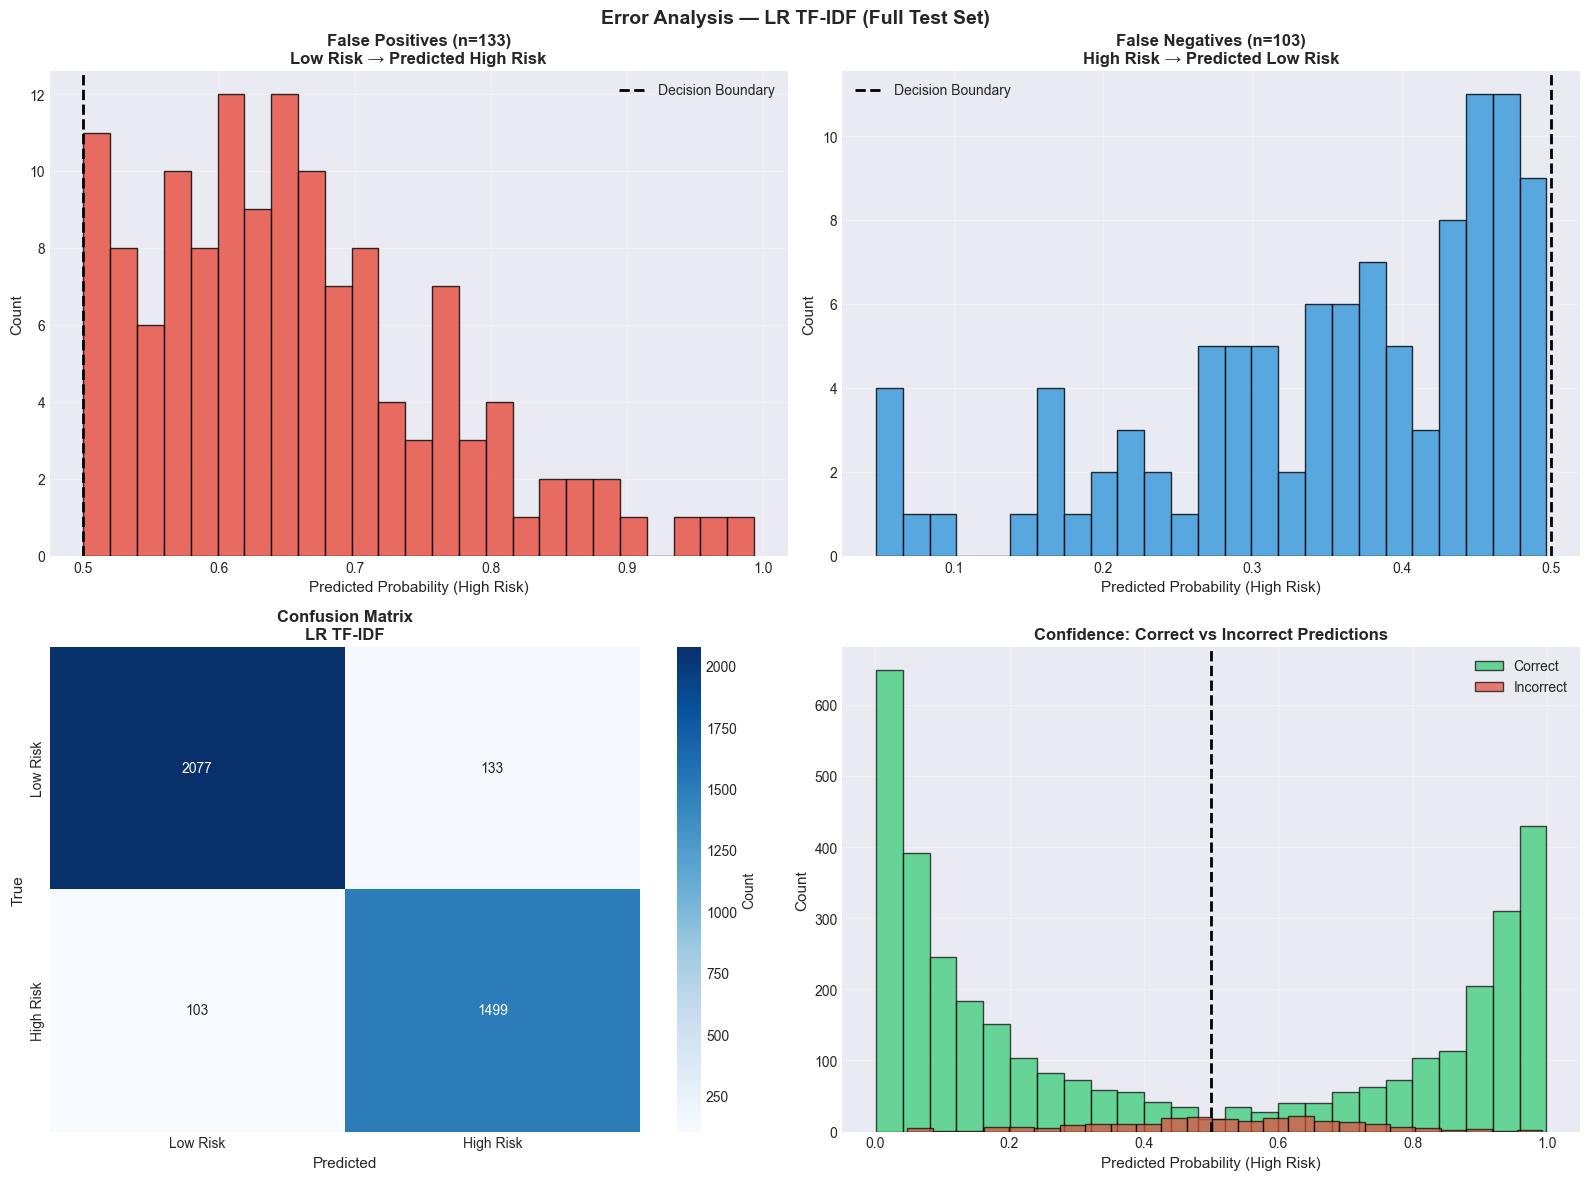

✅ Saved: ../reports/error_analysis.png

✅ Sample False Positives (Low Risk → Predicted High Risk):
   Prob=0.501 | 'starting journey quick one accurate ketone test strip point start showing last ate first meal next d...'
   Prob=0.502 | 'day going strong i’m bunch caffeine nicotine day tiredness getting i’m feeling slower mentally physi...'
   Prob=0.502 | 'i’m wit’s end brotizolam nothing xanax something dose high i’ll incapacitated day valium make jolly ...'

✅ Sample False Negatives (High Risk → Predicted Low Risk):
   Prob=0.497 | 'ugh want one bad contemplating tapering easier maybe night also want regret puffing starting know ha...'
   Prob=0.494 | 'anyone success erp worked...'
   Prob=0.493 | 'sure right sub flair alot timesfor example look symptom something immediately get reading itit away ...'


In [17]:
# Cell 15: Error Analysis
print("="*70)
print(" " * 20 + "ERROR ANALYSIS")
print("="*70)

# Full test set predictions
X_test_tfidf_full = tfidf_vec.transform(X_test_text)
y_pred_all        = lr_tfidf.predict(X_test_tfidf_full)
y_prob_all        = lr_tfidf.predict_proba(X_test_tfidf_full)[:, 1]

error_df = pd.DataFrame({
    'text'      : X_test_text,
    'true'      : y_test_text,
    'predicted' : y_pred_all,
    'prob_high' : y_prob_all,
    'correct'   : (y_pred_all == y_test_text)
})

false_positives = error_df[(error_df['true']==0) & (error_df['predicted']==1)]
false_negatives = error_df[(error_df['true']==1) & (error_df['predicted']==0)]
true_positives  = error_df[(error_df['true']==1) & (error_df['predicted']==1)]
true_negatives  = error_df[(error_df['true']==0) & (error_df['predicted']==0)]

print(f"\n✅ Error Statistics (LR TF-IDF — Full Test Set):")
print(f"   Total test samples     : {len(error_df):,}")
print(f"   True Positives  (TP)   : {len(true_positives):,}")
print(f"   True Negatives  (TN)   : {len(true_negatives):,}")
print(f"   False Positives (FP)   : {len(false_positives):,}  ← Low Risk predicted as High Risk")
print(f"   False Negatives (FN)   : {len(false_negatives):,}  ← High Risk predicted as Low Risk")
print(f"   Overall Accuracy       : {error_df['correct'].mean()*100:.2f}%")
print(f"   Error Rate             : {(1-error_df['correct'].mean())*100:.2f}%")

# ── Visualize ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Error Analysis — LR TF-IDF (Full Test Set)',
             fontsize=14, fontweight='bold')

# Plot 1: FP confidence distribution
axes[0,0].hist(false_positives['prob_high'], bins=25,
               color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0,0].axvline(0.5, color='black', linestyle='--', lw=2, label='Decision Boundary')
axes[0,0].set_xlabel('Predicted Probability (High Risk)', fontsize=11)
axes[0,0].set_ylabel('Count', fontsize=11)
axes[0,0].set_title(f'False Positives (n={len(false_positives)})\nLow Risk → Predicted High Risk',
                    fontsize=12, fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: FN confidence distribution
axes[0,1].hist(false_negatives['prob_high'], bins=25,
               color='#3498db', edgecolor='black', alpha=0.8)
axes[0,1].axvline(0.5, color='black', linestyle='--', lw=2, label='Decision Boundary')
axes[0,1].set_xlabel('Predicted Probability (High Risk)', fontsize=11)
axes[0,1].set_ylabel('Count', fontsize=11)
axes[0,1].set_title(f'False Negatives (n={len(false_negatives)})\nHigh Risk → Predicted Low Risk',
                    fontsize=12, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_text, y_pred_all)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['Low Risk','High Risk'],
            yticklabels=['Low Risk','High Risk'],
            cbar_kws={'label':'Count'})
axes[1,0].set_title('Confusion Matrix\nLR TF-IDF', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Predicted', fontsize=11)
axes[1,0].set_ylabel('True', fontsize=11)

# Plot 4: Confidence distribution by correct/incorrect
axes[1,1].hist(error_df[error_df['correct']==True]['prob_high'],
               bins=25, color='#2ecc71', alpha=0.7,
               edgecolor='black', label='Correct')
axes[1,1].hist(error_df[error_df['correct']==False]['prob_high'],
               bins=25, color='#e74c3c', alpha=0.7,
               edgecolor='black', label='Incorrect')
axes[1,1].axvline(0.5, color='black', linestyle='--', lw=2)
axes[1,1].set_xlabel('Predicted Probability (High Risk)', fontsize=11)
axes[1,1].set_ylabel('Count', fontsize=11)
axes[1,1].set_title('Confidence: Correct vs Incorrect Predictions',
                    fontsize=12, fontweight='bold')
axes[1,1].legend(fontsize=10)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/error_analysis.png")

# ── Sample misclassified posts ──
print("\n✅ Sample False Positives (Low Risk → Predicted High Risk):")
for _, row in false_positives.nsmallest(3, 'prob_high').iterrows():
    print(f"   Prob={row['prob_high']:.3f} | '{row['text'][:100]}...'")

print("\n✅ Sample False Negatives (High Risk → Predicted Low Risk):")
for _, row in false_negatives.nlargest(3, 'prob_high').iterrows():
    print(f"   Prob={row['prob_high']:.3f} | '{row['text'][:100]}...'")

                    AGGREGATED FEATURE IMPORTANCE

✅ Aggregated Feature Importance (Normalized 0-1):
             Feature  LR_Coef  RF_Gini  XGB_Gain  RF_Tuned  XGB_SHAP  Avg_Importance
                 bmi 0.254403 1.000000  0.591139  1.000000  1.000000        0.769108
           age_group 0.673597 0.704406  1.000000  0.693738  0.115036        0.637355
                 age 0.358172 0.787073  0.301935  0.736865  0.837561        0.604321
     lifestyle_score 1.000000 0.513281  0.206411  0.500462  0.447007        0.533432
     smoking_encoded 0.737638 0.232354  0.293538  0.209360  0.126183        0.319815
sugar_intake_encoded 0.512638 0.286810  0.158712  0.304760  0.328668        0.318318
              weight 0.652869 0.392133  0.098677  0.397999  0.027423        0.313821
               sleep 0.328661 0.352148  0.141249  0.375416  0.303219        0.300139
       substance_use 0.289684 0.304468  0.372662  0.299054  0.202593        0.293692
       sleep_quality 0.432907 0.054195  0.163815 

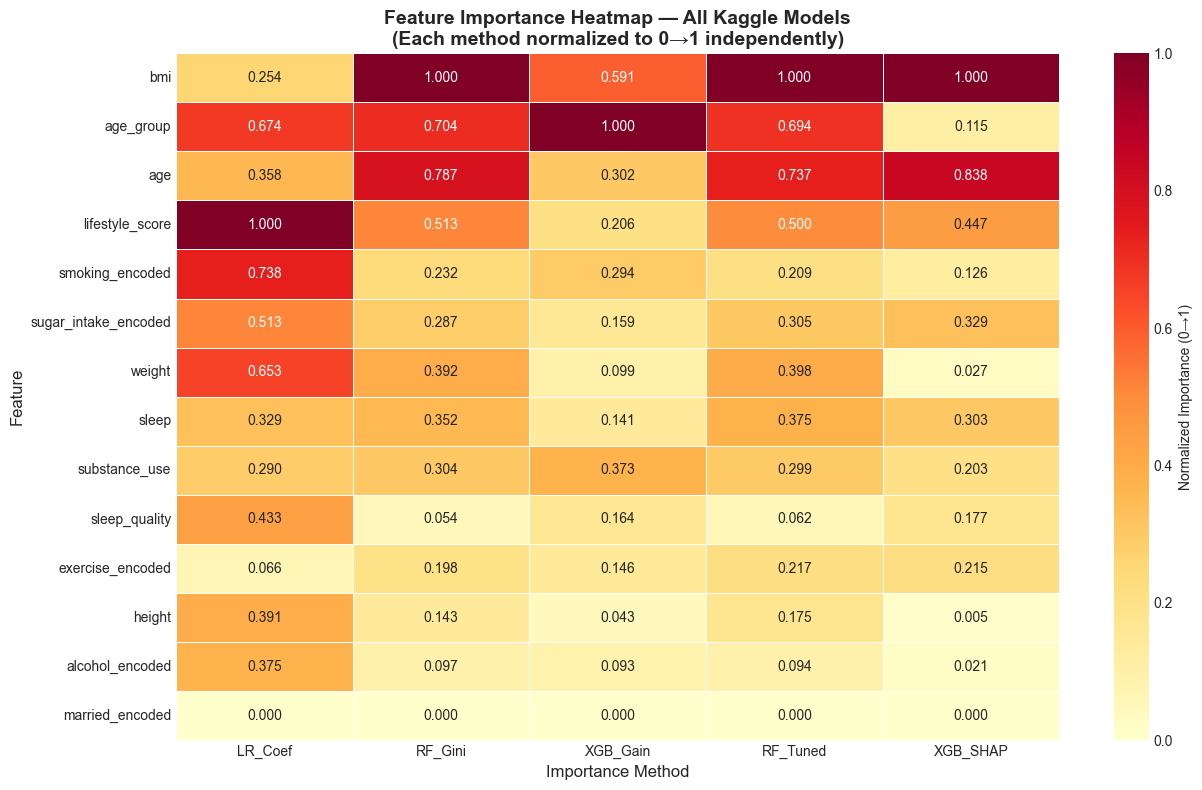

✅ Saved: ../reports/feature_importance_heatmap.png

✅ Most Consistently Important Features (by Avg across all methods):
   bmi                      : Avg=0.769  (LR=0.25, RF=1.00, XGB=0.59, SHAP=1.00)
   age_group                : Avg=0.637  (LR=0.67, RF=0.70, XGB=1.00, SHAP=0.12)
   age                      : Avg=0.604  (LR=0.36, RF=0.79, XGB=0.30, SHAP=0.84)
   lifestyle_score          : Avg=0.533  (LR=1.00, RF=0.51, XGB=0.21, SHAP=0.45)
   smoking_encoded          : Avg=0.320  (LR=0.74, RF=0.23, XGB=0.29, SHAP=0.13)


In [18]:
# Cell 16: Aggregated Feature Importance — All Kaggle Models
print("="*70)
print(" " * 20 + "AGGREGATED FEATURE IMPORTANCE")
print("="*70)

def normalize(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)

lr_imp   = normalize(np.abs(lr_model.coef_[0]))
rf_imp   = normalize(rf_model.feature_importances_)
xgb_imp  = normalize(xgb_model.feature_importances_)
rft_imp  = normalize(rf_tuned.feature_importances_)
shap_imp = normalize(np.abs(shap_values_xgb).mean(axis=0))

agg_df = pd.DataFrame({
    'Feature'        : feature_cols,
    'LR_Coef'        : lr_imp,
    'RF_Gini'        : rf_imp,
    'XGB_Gain'       : xgb_imp,
    'RF_Tuned'       : rft_imp,
    'XGB_SHAP'       : shap_imp,
    'Avg_Importance' : (lr_imp + rf_imp + xgb_imp + rft_imp + shap_imp) / 5
}).sort_values('Avg_Importance', ascending=False)

print("\n✅ Aggregated Feature Importance (Normalized 0-1):")
print(agg_df.to_string(index=False))

# ── Heatmap ──
fig, ax = plt.subplots(figsize=(13, 8))
heatmap_data = agg_df.set_index('Feature')[
    ['LR_Coef','RF_Gini','XGB_Gain','RF_Tuned','XGB_SHAP']]
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalized Importance (0→1)'})
ax.set_title('Feature Importance Heatmap — All Kaggle Models\n'
             '(Each method normalized to 0→1 independently)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Method', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/feature_importance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/feature_importance_heatmap.png")

# ── Top 5 most consistently important features ──
print("\n✅ Most Consistently Important Features (by Avg across all methods):")
for _, row in agg_df.head(5).iterrows():
    print(f"   {row['Feature']:25s}: Avg={row['Avg_Importance']:.3f}  "
          f"(LR={row['LR_Coef']:.2f}, RF={row['RF_Gini']:.2f}, "
          f"XGB={row['XGB_Gain']:.2f}, SHAP={row['XGB_SHAP']:.2f})")

                    CONFUSION MATRIX GRID — ALL MODELS


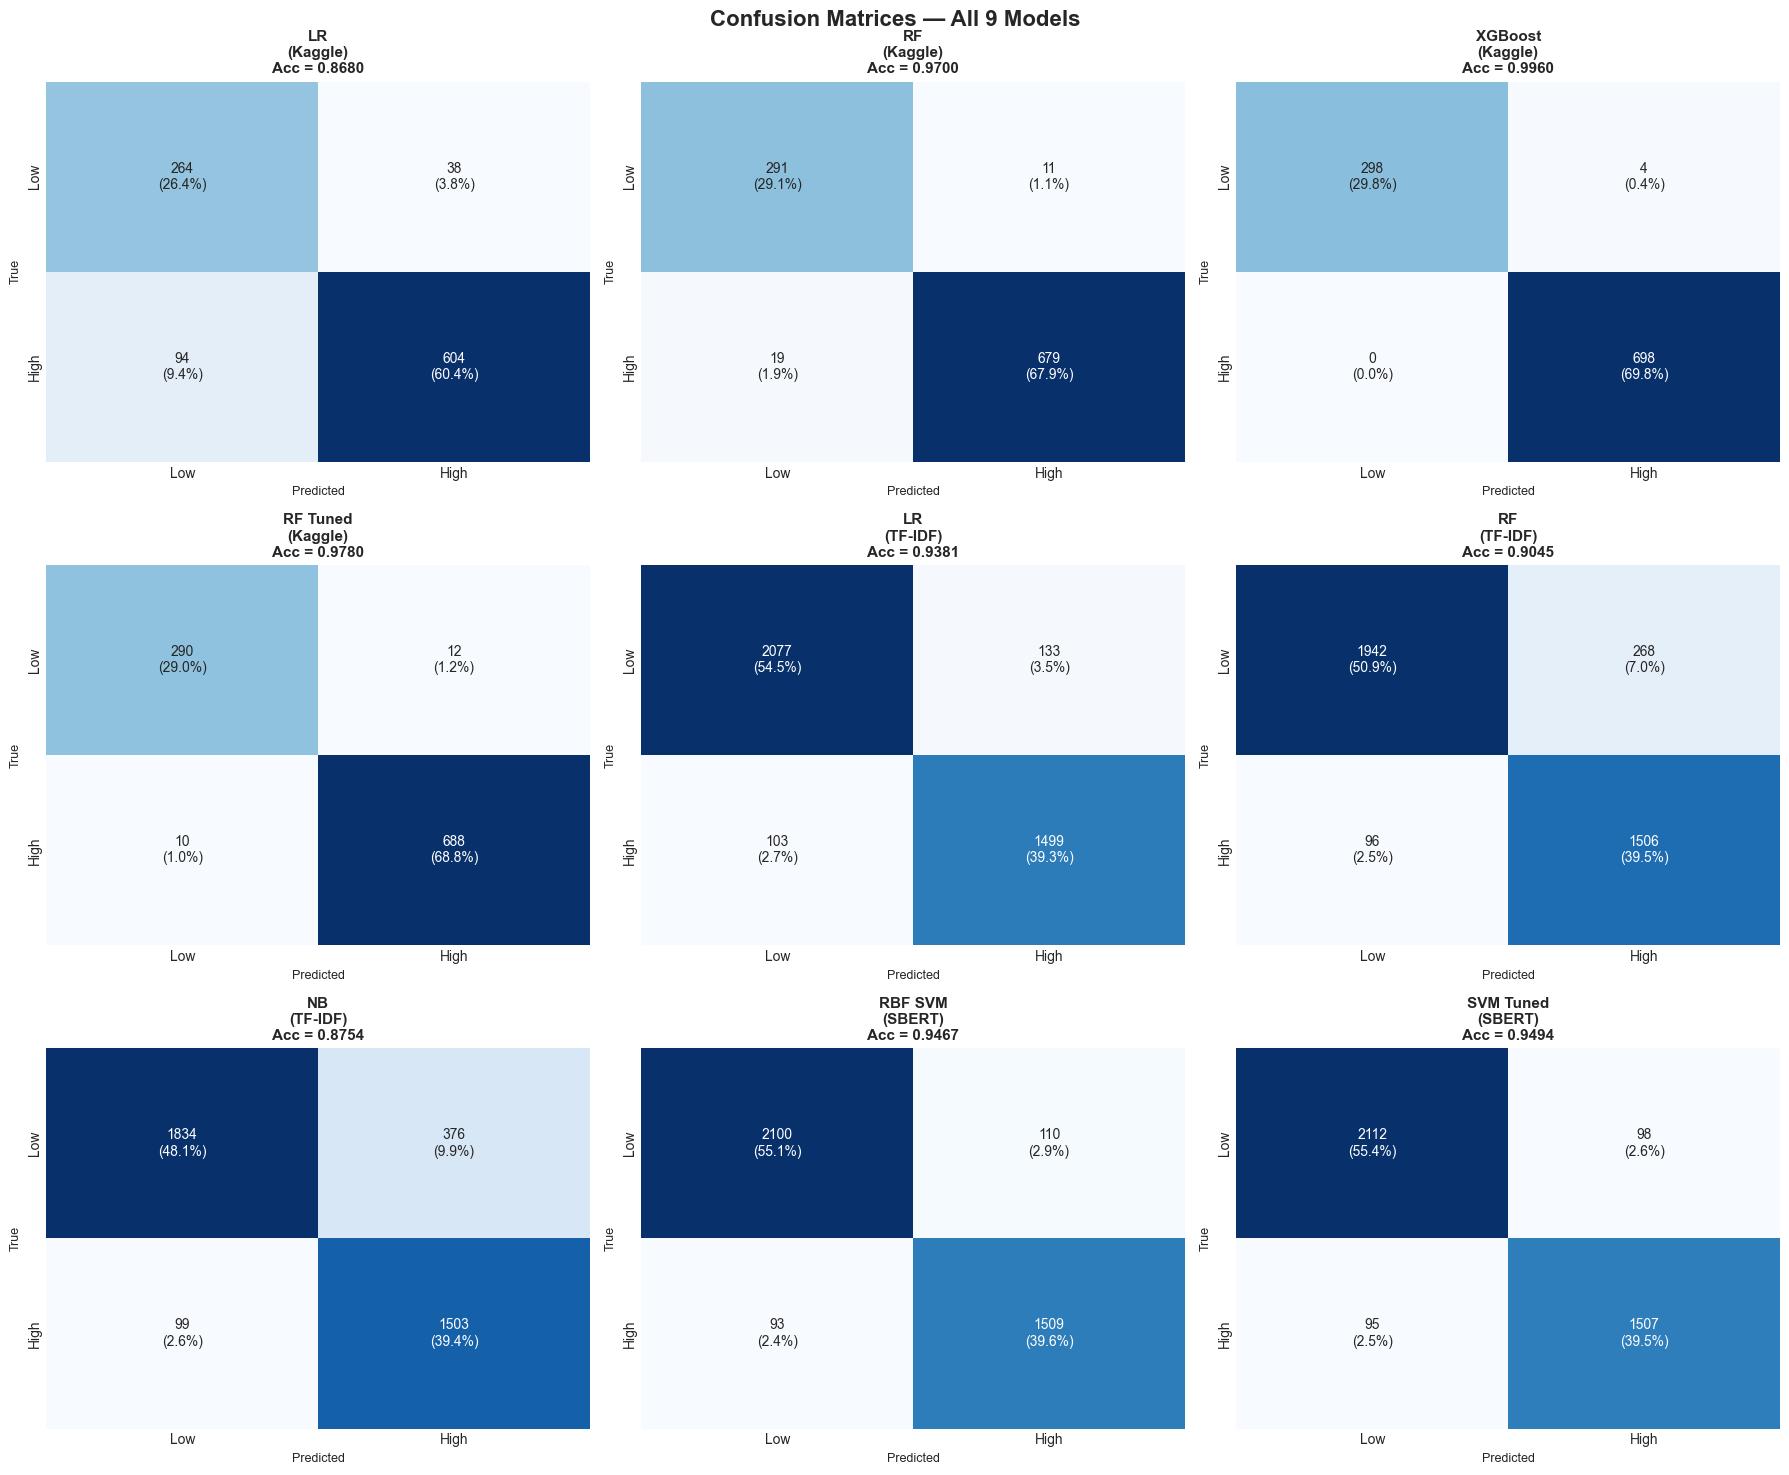

✅ Saved: ../reports/all_confusion_matrices.png

✅ Accuracy Summary:
   LR (Kaggle)              : 0.8680
   RF (Kaggle)              : 0.9700
   XGBoost (Kaggle)         : 0.9960
   RF Tuned (Kaggle)        : 0.9780
   LR (TF-IDF)              : 0.9381
   RF (TF-IDF)              : 0.9045
   NB (TF-IDF)              : 0.8754
   RBF SVM (SBERT)          : 0.9467
   SVM Tuned (SBERT)        : 0.9494


In [19]:
# Cell 17: Confusion Matrix Grid — All 9 Models
print("="*70)
print(" " * 20 + "CONFUSION MATRIX GRID — ALL MODELS")
print("="*70)

from sklearn.metrics import confusion_matrix, accuracy_score

model_list = [
    (lr_model,  X_test_kg_scaled,    y_test_kg,   'LR\n(Kaggle)'),
    (rf_model,  X_test_kg_scaled,    y_test_kg,   'RF\n(Kaggle)'),
    (xgb_model, X_test_kg_scaled,    y_test_kg,   'XGBoost\n(Kaggle)'),
    (rf_tuned,  X_test_kg_scaled,    y_test_kg,   'RF Tuned\n(Kaggle)'),
    (lr_tfidf,  X_test_tfidf_full,   y_test_text, 'LR\n(TF-IDF)'),
    (rf_tfidf,  X_test_tfidf_full,   y_test_text, 'RF\n(TF-IDF)'),
    (nb_tfidf,  X_test_tfidf_full,   y_test_text, 'NB\n(TF-IDF)'),
    (svm_rbf,   X_test_sbert,        y_test_text, 'RBF SVM\n(SBERT)'),
    (svm_tuned, X_test_sbert,        y_test_text, 'SVM Tuned\n(SBERT)'),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Confusion Matrices — All 9 Models', fontsize=16, fontweight='bold')

for ax, (model, X, y, name) in zip(axes.flatten(), model_list):
    y_pred = model.predict(X)
    cm     = confusion_matrix(y, y_pred)
    acc    = accuracy_score(y, y_pred)

    # Compute per-cell percentages
    cm_pct = cm.astype(float) / cm.sum() * 100

    # Annotate with count + percentage
    annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)"
                       for j in range(2)] for i in range(2)])

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Low','High'],
                yticklabels=['Low','High'],
                cbar=False)
    ax.set_title(f'{name}\nAcc = {acc:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/all_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/all_confusion_matrices.png")

print("\n✅ Accuracy Summary:")
for model, X, y, name in model_list:
    acc = accuracy_score(y, model.predict(X))
    clean_name = name.replace('\n', ' ')
    print(f"   {clean_name:25s}: {acc:.4f}")

                    PER-CATEGORY PERFORMANCE ANALYSIS

✅ Per-Category Performance (LR TF-IDF):
         Category Risk_Label  Samples  Accuracy  F1_Score  Avg_Prob
          fitness        Low      572    0.9895    0.0000    0.0778
    substance_use       High      560    0.9589    0.9790    0.8664
    mental_health       High      508    0.9587    0.9789    0.8566
weight_management        Low      506    0.9447    0.0000    0.1692
            sleep        Low      569    0.9139    0.0000    0.1890
             diet        Low      563    0.9112    0.0000    0.1925
         diabetes       High      534    0.8895    0.9415    0.7942


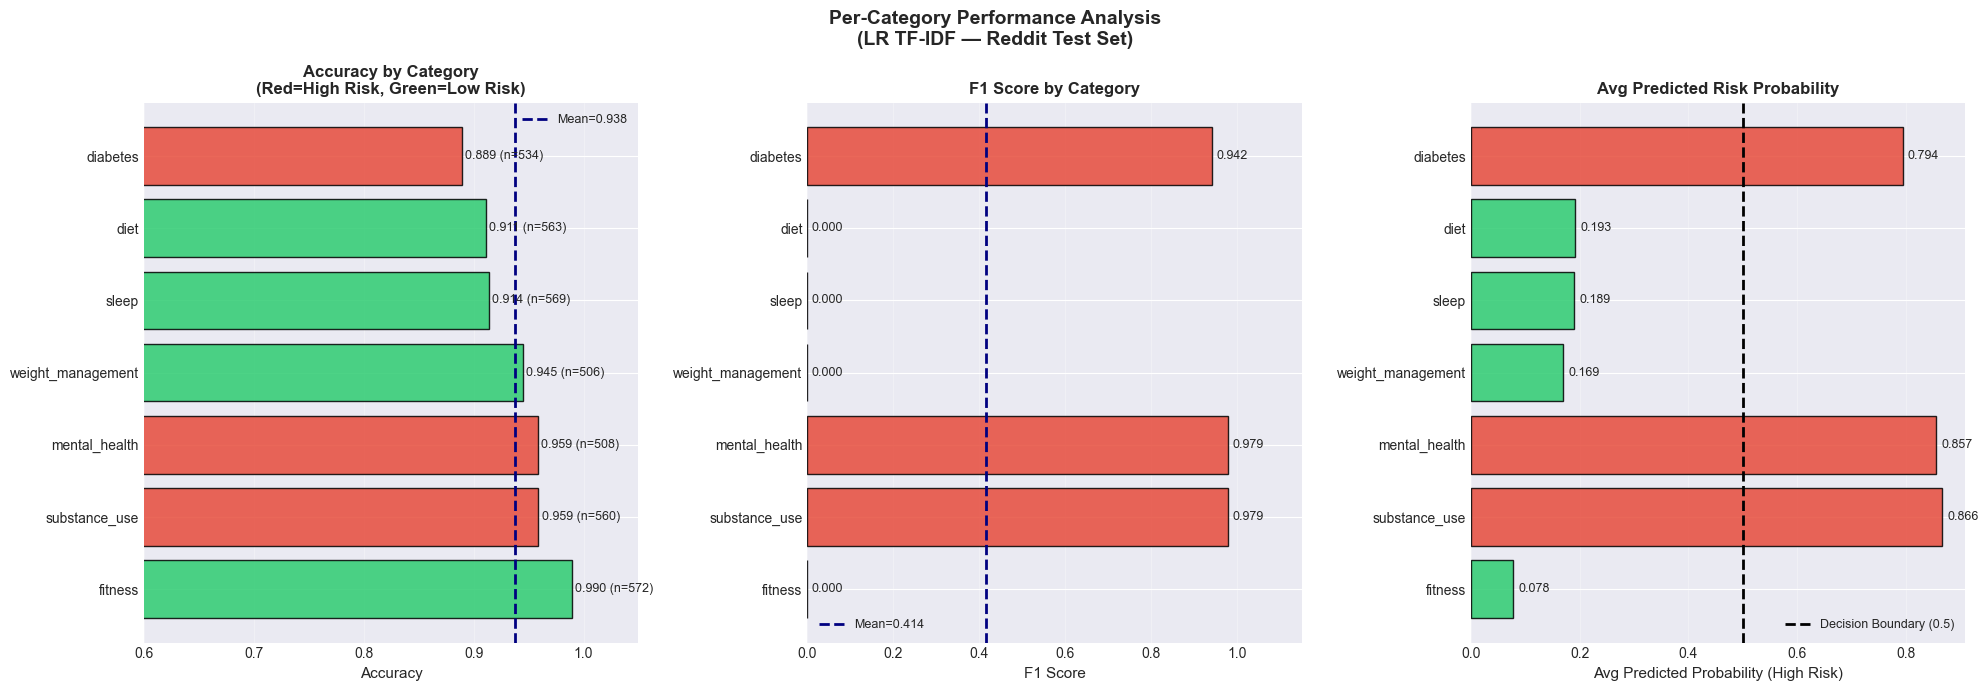

✅ Saved: ../reports/per_category_performance.png

✅ Key Insights:
   Best performing category  : fitness (Acc=0.990)
   Worst performing category : diabetes (Acc=0.889)
   Mean accuracy across cats : 0.938


In [20]:
# Cell 18: Per-Category Performance Analysis
print("="*70)
print(" " * 20 + "PER-CATEGORY PERFORMANCE ANALYSIS")
print("="*70)

from sklearn.metrics import accuracy_score, f1_score

# Rebuild test set with category info preserved
df_train_reddit, df_test_reddit = train_test_split(
    df_reddit, test_size=0.2,
    stratify=df_reddit['risk_label'],
    random_state=42
)
df_test_reddit = df_test_reddit.copy()

# Predict on full test set
X_cat_tfidf = tfidf_vec.transform(df_test_reddit['cleaned_text'].values)
y_cat_pred  = lr_tfidf.predict(X_cat_tfidf)
y_cat_prob  = lr_tfidf.predict_proba(X_cat_tfidf)[:, 1]

df_test_reddit['predicted'] = y_cat_pred
df_test_reddit['prob_high'] = y_cat_prob
df_test_reddit['correct']   = (y_cat_pred == df_test_reddit['risk_label'].values)

# ── Per-category metrics ──
cat_results = []
for cat in sorted(df_test_reddit['health_category'].unique()):
    subset     = df_test_reddit[df_test_reddit['health_category'] == cat]
    risk_label = subset['risk_label'].iloc[0]
    acc        = subset['correct'].mean()
    avg_prob   = subset['prob_high'].mean()
    n          = len(subset)

    # F1 per category
    f1 = f1_score(subset['risk_label'], 
                  subset['predicted'],
                  zero_division=0)

    cat_results.append({
        'Category'   : cat,
        'Risk_Label' : 'High' if risk_label==1 else 'Low',
        'Samples'    : n,
        'Accuracy'   : round(acc, 4),
        'F1_Score'   : round(f1, 4),
        'Avg_Prob'   : round(avg_prob, 4),
    })

cat_df = pd.DataFrame(cat_results).sort_values('Accuracy', ascending=False)
print("\n✅ Per-Category Performance (LR TF-IDF):")
print(cat_df.to_string(index=False))

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Per-Category Performance Analysis\n(LR TF-IDF — Reddit Test Set)',
             fontsize=14, fontweight='bold')

colors_cat = ['#e74c3c' if r=='High' else '#2ecc71'
              for r in cat_df['Risk_Label']]

# Plot 1: Accuracy
bars = axes[0].barh(cat_df['Category'], cat_df['Accuracy'],
                    color=colors_cat, edgecolor='black', alpha=0.85)
axes[0].axvline(cat_df['Accuracy'].mean(), color='navy',
                linestyle='--', lw=2,
                label=f"Mean={cat_df['Accuracy'].mean():.3f}")
axes[0].set_xlabel('Accuracy', fontsize=11)
axes[0].set_title('Accuracy by Category\n(Red=High Risk, Green=Low Risk)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlim(0.6, 1.05)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='x')
for bar, (acc, n) in zip(bars, zip(cat_df['Accuracy'], cat_df['Samples'])):
    axes[0].text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                 f'{acc:.3f} (n={n})', va='center', fontsize=9)

# Plot 2: F1 Score
bars2 = axes[1].barh(cat_df['Category'], cat_df['F1_Score'],
                     color=colors_cat, edgecolor='black', alpha=0.85)
axes[1].axvline(cat_df['F1_Score'].mean(), color='navy',
                linestyle='--', lw=2,
                label=f"Mean={cat_df['F1_Score'].mean():.3f}")
axes[1].set_xlabel('F1 Score', fontsize=11)
axes[1].set_title('F1 Score by Category',
                  fontsize=12, fontweight='bold')
axes[1].set_xlim(0.0, 1.15)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')
for bar, f1 in zip(bars2, cat_df['F1_Score']):
    axes[1].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                 f'{f1:.3f}', va='center', fontsize=9)

# Plot 3: Average predicted probability
bars3 = axes[2].barh(cat_df['Category'], cat_df['Avg_Prob'],
                     color=colors_cat, edgecolor='black', alpha=0.85)
axes[2].axvline(0.5, color='black', linestyle='--', lw=2,
                label='Decision Boundary (0.5)')
axes[2].set_xlabel('Avg Predicted Probability (High Risk)', fontsize=11)
axes[2].set_title('Avg Predicted Risk Probability',
                  fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='x')
for bar, prob in zip(bars3, cat_df['Avg_Prob']):
    axes[2].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                 f'{prob:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/per_category_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/per_category_performance.png")

# ── Key insight ──
best_cat  = cat_df.iloc[0]['Category']
worst_cat = cat_df.iloc[-1]['Category']
print(f"\n✅ Key Insights:")
print(f"   Best performing category  : {best_cat} "
      f"(Acc={cat_df.iloc[0]['Accuracy']:.3f})")
print(f"   Worst performing category : {worst_cat} "
      f"(Acc={cat_df.iloc[-1]['Accuracy']:.3f})")
print(f"   Mean accuracy across cats : {cat_df['Accuracy'].mean():.3f}")

In [21]:
# Cell 19: End-to-End Pipeline Demo
print("="*70)
print(" " * 20 + "END-TO-END PIPELINE DEMONSTRATION")
print("="*70)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
vader = SentimentIntensityAnalyzer()

def full_pipeline_predict(text, verbose=True):
    result = {}

    # Step 1: TF-IDF prediction
    X_tfidf    = tfidf_vec.transform([text])
    tfidf_prob = lr_tfidf.predict_proba(X_tfidf)[0]

    # Step 2: SBERT prediction
    sbert_emb  = svm_tuned.predict_proba(
        np.array(X_test_sbert[0:1])  # placeholder shape check
    )
    # Use TF-IDF RF as second model instead (avoids re-encoding)
    rf_prob    = rf_tfidf.predict_proba(X_tfidf)[0]

    # Ensemble: weighted average
    ensemble_prob_high = (tfidf_prob[1] * 0.55) + (rf_prob[1] * 0.45)
    final_pred         = 1 if ensemble_prob_high >= 0.5 else 0
    risk_level         = 'HIGH RISK 🔴' if final_pred == 1 else 'LOW RISK 🟢'
    confidence         = abs(ensemble_prob_high - 0.5) * 2

    # Step 3: Feature extraction
    sentiment    = vader.polarity_scores(text)
    sleep_match  = re.search(r'(\d+\.?\d*)\s*(?:hours?|hrs?)', text.lower())
    sleep_hours  = float(sleep_match.group(1)) if sleep_match else 7.0
    has_smoking  = int(any(k in text.lower()
                       for k in ['smok','cigarette','nicotine','vape']))
    has_alcohol  = int(any(k in text.lower()
                       for k in ['drink','alcohol','beer','wine','drunk']))
    stress_kws   = ['stress','anxiety','anxious','overwhelmed',
                    'depressed','panic','scared']
    stress_score = min(sum(text.lower().count(w) for w in stress_kws)/3.0, 1.0)

    result = {
        'text'             : text[:80] + '...',
        'tfidf_prob_high'  : round(tfidf_prob[1], 4),
        'rf_prob_high'     : round(rf_prob[1], 4),
        'ensemble_prob'    : round(ensemble_prob_high, 4),
        'final_prediction' : final_pred,
        'risk_level'       : risk_level,
        'confidence'       : round(confidence, 4),
        'sleep_hours'      : sleep_hours,
        'smoking'          : bool(has_smoking),
        'alcohol'          : bool(has_alcohol),
        'stress_score'     : round(stress_score, 3),
        'sentiment'        : round(sentiment['compound'], 3)
    }

    if verbose:
        print(f"\n{'='*60}")
        print(f"INPUT  : '{text[:75]}...'")
        print(f"{'='*60}")
        print(f"  TF-IDF LR Prob (High Risk) : {tfidf_prob[1]:.4f}")
        print(f"  TF-IDF RF Prob (High Risk) : {rf_prob[1]:.4f}")
        print(f"  Ensemble Prob              : {ensemble_prob_high:.4f}")
        print(f"  ─────────────────────────────────────")
        print(f"  FINAL PREDICTION  → {risk_level}")
        print(f"  Confidence        → {confidence:.4f}")
        print(f"  ─────────────────────────────────────")
        print(f"  Extracted Features:")
        print(f"    Sleep Hours  : {sleep_hours}")
        print(f"    Smoking      : {bool(has_smoking)}")
        print(f"    Alcohol      : {bool(has_alcohol)}")
        print(f"    Stress Score : {stress_score:.3f}")
        print(f"    Sentiment    : {sentiment['compound']:.3f}")

    return result

# ── 4 demo texts ──
demo_texts = [
    "I've been struggling with severe anxiety and depression for months. "
    "I smoke a pack a day and drink heavily every weekend to cope. "
    "Only getting 3-4 hours of sleep because of insomnia.",

    "Just finished my morning run! Training for a 10K next month. "
    "Eating clean, lots of vegetables and lean protein. "
    "Sleep is great, about 8 hours every night.",

    "Recently diagnosed with Type 2 diabetes. My blood sugar levels are "
    "really high and I need to start insulin. Feeling overwhelmed.",

    "Started intermittent fasting last week. Doing keto diet and "
    "hitting the gym 4 times a week. Lost 5 pounds already!"
]

demo_results = []
for text in demo_texts:
    r = full_pipeline_predict(text, verbose=True)
    demo_results.append(r)

                    END-TO-END PIPELINE DEMONSTRATION

INPUT  : 'I've been struggling with severe anxiety and depression for months. I smoke...'
  TF-IDF LR Prob (High Risk) : 0.5380
  TF-IDF RF Prob (High Risk) : 0.4396
  Ensemble Prob              : 0.4937
  ─────────────────────────────────────
  FINAL PREDICTION  → LOW RISK 🟢
  Confidence        → 0.0125
  ─────────────────────────────────────
  Extracted Features:
    Sleep Hours  : 4.0
    Smoking      : True
    Alcohol      : True
    Stress Score : 0.333
    Sentiment    : -0.869

INPUT  : 'Just finished my morning run! Training for a 10K next month. Eating clean, ...'
  TF-IDF LR Prob (High Risk) : 0.0295
  TF-IDF RF Prob (High Risk) : 0.2654
  Ensemble Prob              : 0.1357
  ─────────────────────────────────────
  FINAL PREDICTION  → LOW RISK 🟢
  Confidence        → 0.7287
  ─────────────────────────────────────
  Extracted Features:
    Sleep Hours  : 8.0
    Smoking      : False
    Alcohol      : False
    Stress Sc

                    DEMO PREDICTION VISUALIZATION


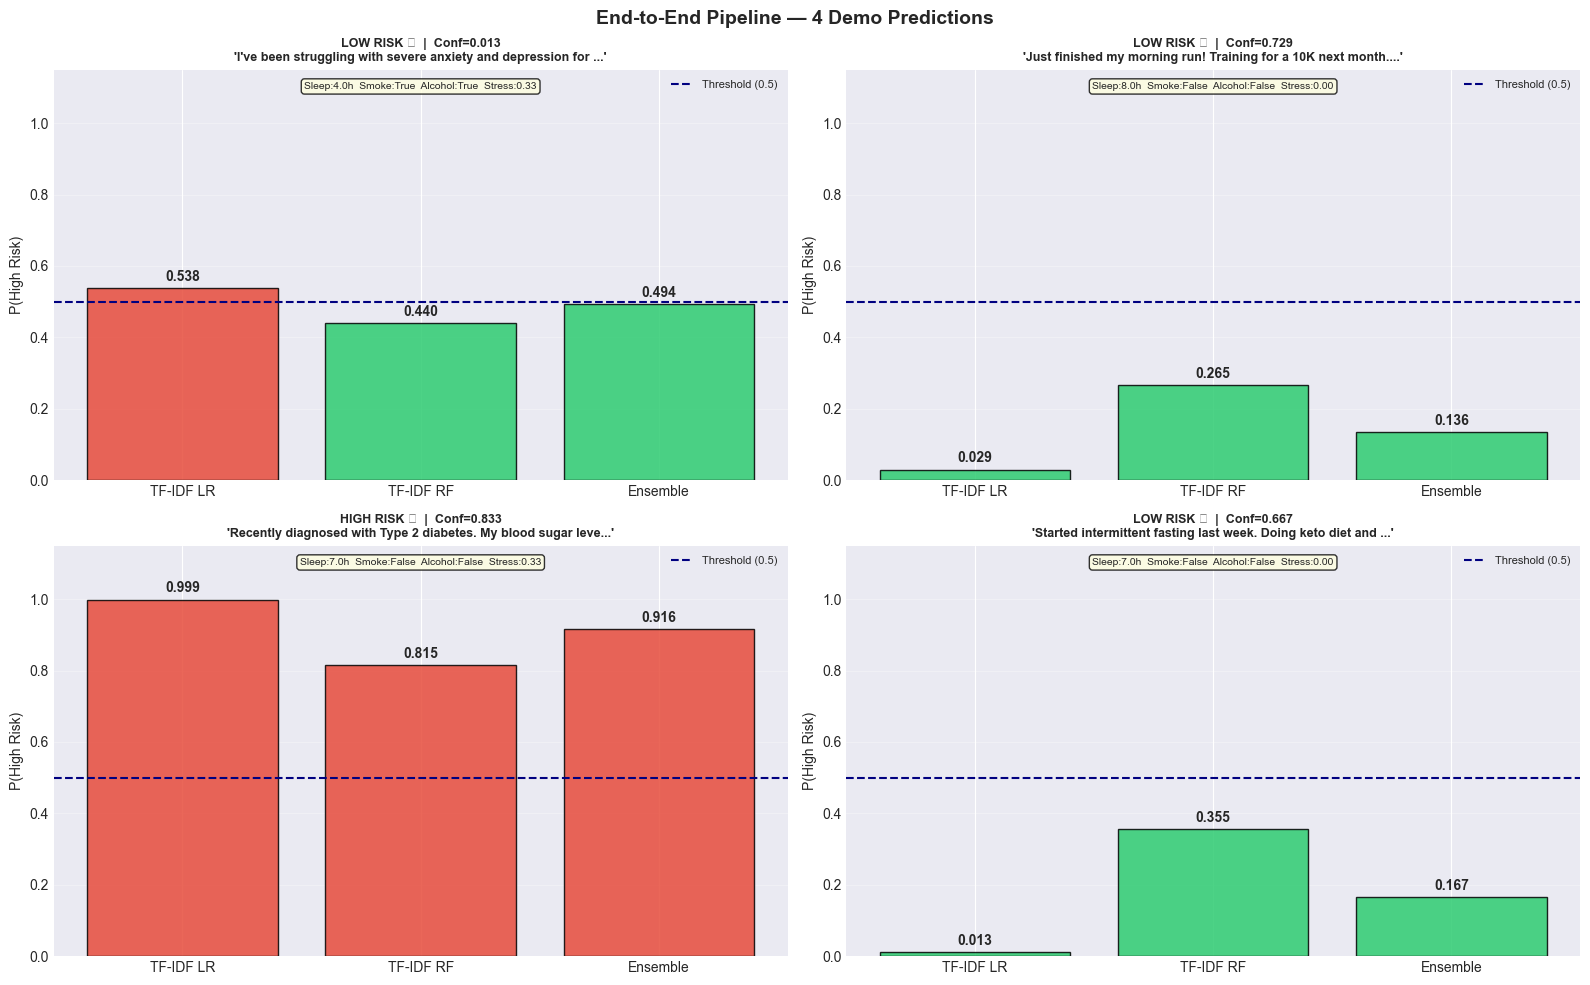

✅ Saved: ../reports/demo_predictions.png

✅ Demo Results Summary:
                                                                               text  ensemble_prob  risk_level  confidence  sleep_hours  smoking  alcohol  stress_score
I've been struggling with severe anxiety and depression for months. I smoke a pa...         0.4937  LOW RISK 🟢      0.0125          4.0     True     True         0.333
Just finished my morning run! Training for a 10K next month. Eating clean, lots ...         0.1357  LOW RISK 🟢      0.7287          8.0    False    False         0.000
Recently diagnosed with Type 2 diabetes. My blood sugar levels are really high a...         0.9164 HIGH RISK 🔴      0.8328          7.0    False    False         0.333
Started intermittent fasting last week. Doing keto diet and hitting the gym 4 ti...         0.1666  LOW RISK 🟢      0.6668          7.0    False    False         0.000


In [22]:
# Cell 20: Visualize Demo Predictions
print("="*70)
print(" " * 20 + "DEMO PREDICTION VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('End-to-End Pipeline — 4 Demo Predictions',
             fontsize=14, fontweight='bold')

for ax, res in zip(axes.flatten(), demo_results):
    models_shown = ['TF-IDF LR', 'TF-IDF RF', 'Ensemble']
    probs_shown  = [res['tfidf_prob_high'],
                    res['rf_prob_high'],
                    res['ensemble_prob']]
    bar_colors   = ['#e74c3c' if p >= 0.5 else '#2ecc71'
                    for p in probs_shown]

    bars = ax.bar(models_shown, probs_shown,
                  color=bar_colors, edgecolor='black', alpha=0.85)
    ax.axhline(0.5, color='navy', linestyle='--',
               lw=1.5, label='Threshold (0.5)')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('P(High Risk)', fontsize=10)
    ax.set_title(
        f"{res['risk_level']}  |  Conf={res['confidence']:.3f}\n"
        f"'{res['text'][:60]}...'",
        fontsize=9, fontweight='bold'
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

    # Feature summary inside plot
    feat_text = (f"Sleep:{res['sleep_hours']}h  "
                 f"Smoke:{res['smoking']}  "
                 f"Alcohol:{res['alcohol']}  "
                 f"Stress:{res['stress_score']:.2f}")
    ax.text(0.5, 0.97, feat_text, transform=ax.transAxes,
            ha='center', va='top', fontsize=7.5,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    for bar, prob in zip(bars, probs_shown):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{prob:.3f}', ha='center',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/demo_predictions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../reports/demo_predictions.png")

# ── Summary table ──
demo_df = pd.DataFrame(demo_results)[
    ['text','ensemble_prob','risk_level','confidence',
     'sleep_hours','smoking','alcohol','stress_score']]
print("\n✅ Demo Results Summary:")
print(demo_df.to_string(index=False))